In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Your project root (adjust if different)
PROJ = "/content/drive/MyDrive/Imbalance"

import os, sys
os.makedirs(PROJ, exist_ok=True)
%cd $PROJ

# standard folders (you likely already have these)
for d in ["splits","ckpts","metrics","figures"]:
    os.makedirs(d, exist_ok=True)

# keep src/ on path if you already have helpers there
if os.path.isdir("src"):
    sys.path.append(os.path.join(PROJ, "src"))

print("Working dir:", PROJ)


Mounted at /content/drive
/content/drive/MyDrive/Imbalance
Working dir: /content/drive/MyDrive/Imbalance


In [3]:
import os, json, math, random
import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class_labels = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
K = len(class_labels)


Device: cuda


In [4]:
# CIFAR-10 transforms (same as your baseline)
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
])
test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
])

train_data = datasets.CIFAR10("./dataset_cache", train=True,  download=True, transform=train_tf)
test_data  = datasets.CIFAR10("./dataset_cache", train=False, download=True, transform=test_tf)

test_loader = DataLoader(test_data, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

# Load all three splits created earlier (lt.json, ss.json, as.json)
SPLITS = {}
for name in ["lt","ss","as"]:
    path = os.path.join("splits", f"{name}.json")
    if os.path.exists(path):
        with open(path) as f:
            data = json.load(f)
        SPLITS[name] = {
            "indices": data["indices"],
            "counts": {int(k): int(v) for k,v in data["counts"].items()}
        }
        print(f"Loaded split '{name.upper()}': {len(SPLITS[name]['indices'])} images")
    else:
        print(f"[WARN] Missing: {path}")

assert len(SPLITS)>0, "No splits found. Run data_splits first."


Loaded split 'LT': 16191 images
Loaded split 'SS': 27500 images
Loaded split 'AS': 9500 images


In [5]:

def resnet18_cifar(num_classes=10):
    m = models.resnet18(weights=None)
    m.conv1 = nn.Conv2d(3,64,3,1,1,bias=False)
    m.maxpool = nn.Identity()
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

def densenet121_cifar(num_classes=10):
    m = models.densenet121(weights=None)
    m.features.conv0 = nn.Conv2d(3,64,3,1,1,bias=False)
    m.features.pool0 = nn.Identity()
    m.classifier = nn.Linear(m.classifier.in_features, num_classes)
    return m

def make_model(backbone, num_classes=10):
    if backbone == "resnet18":   return resnet18_cifar(num_classes)
    if backbone == "densenet121":return densenet121_cifar(num_classes)
    raise ValueError(backbone)


In [6]:
def make_plain_loader(train_dataset, indices, batch_size):
    return DataLoader(Subset(train_dataset, indices),
                      batch_size=batch_size, shuffle=True,
                      num_workers=2, pin_memory=True, drop_last=True)

def make_wrs_loader(train_dataset, indices, counts, batch_size):
    targets = np.array(train_dataset.targets)[indices]
    class_counts = np.zeros(K, dtype=np.float32)
    for c in range(K):
        class_counts[c] = (targets==c).sum()
    class_counts = np.maximum(class_counts, 1.0)
    class_weights = 1.0/class_counts
    sample_weights = class_weights[targets]
    sampler = WeightedRandomSampler(torch.tensor(sample_weights, dtype=torch.float),
                                    num_samples=len(indices), replacement=True)
    return DataLoader(Subset(train_dataset, indices),
                      batch_size=batch_size, sampler=sampler,
                      num_workers=2, pin_memory=True, drop_last=True)

def make_ros_loader(train_dataset, indices, counts, batch_size):
    # naive ROS: sample with replacement until the largest class size
    targets = np.array(train_dataset.targets)[indices]
    per_class = {c: np.where(targets==c)[0] for c in range(K)}
    max_n = max(len(v) for v in per_class.values())
    new_sub_idxs = []
    for c, idxs in per_class.items():
        if len(idxs)==0: continue
        take = np.random.choice(idxs, size=max_n, replace=True)
        new_sub_idxs.extend(take.tolist())
    np.random.shuffle(new_sub_idxs)
    sub = Subset(Subset(train_dataset, indices), new_sub_idxs)
    return DataLoader(sub, batch_size=batch_size, shuffle=True,
                      num_workers=2, pin_memory=True, drop_last=True)


In [7]:
def rand_bbox(size, lam):
    H, W = size[-2], size[-1]
    cut_rat = math.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)
    cx = np.random.randint(W);  cy = np.random.randint(H)
    x1 = np.clip(cx - cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y2 = np.clip(cy + cut_h // 2, 0, H)
    return x1, y1, x2, y2

def apply_mixup(x, y, alpha=0.2):
    if alpha <= 0: return x, y, None, 1.0
    lam = np.random.beta(alpha, alpha)
    perms = torch.randperm(x.size(0), device=x.device)
    x2 = x[perms];  y2 = y[perms]
    x_m = lam*x + (1-lam)*x2
    return x_m, y, y2, lam

def apply_cutmix(x, y, alpha=1.0):
    if alpha <= 0: return x, y, None, 1.0
    lam = np.random.beta(alpha, alpha)
    perms = torch.randperm(x.size(0), device=x.device)
    x2 = x[perms];  y2 = y[perms]
    x1,y1,x2b,y2b = rand_bbox(x.size(), lam)
    x_cut = x.clone()
    x_cut[:,:, y1:y2b, x1:x2b] = x2[:,:, y1:y2b, x1:x2b]
    lam = 1 - ((x2b-x1)*(y2b-y1) / (x.size(-1)*x.size(-2)))
    return x_cut, y, y2, lam

def apply_patchmix(x, y, patch_frac=0.5):
    # simple random patch paste (label 50/50)
    if patch_frac <= 0: return x, y, None, 1.0
    perms = torch.randperm(x.size(0), device=x.device)
    x2 = x[perms];  y2 = y[perms]
    H, W = x.size(-2), x.size(-1)
    ph, pw = int(H*patch_frac), int(W*patch_frac)
    y1 = np.random.randint(0, H-ph+1); x1 = np.random.randint(0, W-pw+1)
    x_pm = x.clone()
    x_pm[:,:, y1:y1+ph, x1:x1+pw] = x2[:,:, y1:y1+ph, x1:x1+pw]
    lam = 0.5
    return x_pm, y, y2, lam


mix up / cutmix

In [8]:
def train_one_epoch(model, loader, criterion, opt,
                    use_mixup=False, use_cutmix=False, use_patchmix=False,
                    mixup_alpha=0.2, cutmix_alpha=1.0, patchmix_frac=0.5):
    model.train()
    loss_sum, acc_sum, n = 0.0, 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)

        # choose augmentation (only one applied per batch for clarity)
        if use_mixup:
            x, y1, y2, lam = apply_mixup(x,y,alpha=mixup_alpha)
        elif use_cutmix:
            x, y1, y2, lam = apply_cutmix(x,y,alpha=cutmix_alpha)
        elif use_patchmix:
            x, y1, y2, lam = apply_patchmix(x,y,patch_frac=patchmix_frac)
        else:
            y1, y2, lam = y, None, 1.0

        logits = model(x)
        if y2 is None:
            loss = criterion(logits, y1)
            preds = logits.argmax(1)
        else:
            loss = lam*criterion(logits, y1) + (1-lam)*criterion(logits, y2)
            preds = logits.argmax(1)

        opt.zero_grad(); loss.backward(); opt.step()

        bs = y.size(0)
        loss_sum += loss.item()*bs
        acc_sum  += (preds==y).float().sum().item()  # note: measured vs true y
        n        += bs

    return loss_sum/n, acc_sum/n

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    loss_sum, acc_sum, n = 0.0, 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        preds = logits.argmax(1)
        bs = y.size(0)
        loss_sum += loss.item()*bs
        acc_sum  += (preds==y).float().sum().item()
        n        += bs
    return loss_sum/n, acc_sum/n

@torch.no_grad()
def get_preds(model, loader, device):
    model.eval()
    yp, yt = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        yp.append(logits.argmax(1).cpu().numpy())
        yt.append(y.numpy())
    return np.concatenate(yt), np.concatenate(yp)

def confusion_matrix(y_true, y_pred, K=10):
    M = np.zeros((K,K), dtype=np.int32)
    for t,p in zip(y_true, y_pred):
        M[t,p]+=1
    return M

def macro_f1(cm):
    f1s = []
    for c in range(cm.shape[0]):
        tp = cm[c,c]
        fp = cm[:,c].sum()-tp
        fn = cm[c,:].sum()-tp
        prec = tp/(tp+fp+1e-9)
        rec  = tp/(tp+fn+1e-9)
        f1 = 2*prec*rec/(prec+rec+1e-9)
        f1s.append(f1)
    return float(np.mean(f1s))

def balanced_acc(cm):
    recalls = []
    for c in range(cm.shape[0]):
        tp = cm[c,c]
        fn = cm[c,:].sum()-tp
        recalls.append(tp/(tp+fn+1e-9))
    return float(np.mean(recalls))


patch mix

In [9]:
def show_strip(imgs, title, outpath):
    """
    Accepts either:
      - a batch tensor of shape (B,C,H,W), OR
      - a list of CxHxW tensors.
    Saves a horizontal strip of up to 8 images.
    """
    import torch, numpy as np, matplotlib.pyplot as plt

    # Convert to a batch tensor
    if isinstance(imgs, torch.Tensor):
        grid = imgs.detach().cpu()            # (B,C,H,W)
    else:
        grid = torch.stack([t.detach().cpu() for t in imgs], dim=0)  # list -> (B,C,H,W)

    n = min(8, grid.size(0))
    grid = grid[:n]

    # de-normalize if data was in [-1,1]
    grid = (grid * 0.5 + 0.5).clamp(0, 1)

    # concatenate along width to make a strip
    concat = torch.cat([grid[i] for i in range(n)], dim=2)  # (C,H,n*W)

    fig, ax = plt.subplots(figsize=(8, 1.2))
    ax.imshow(np.transpose(concat.numpy(), (1, 2, 0)))
    ax.axis('off')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(outpath, dpi=160)
    plt.show()


@torch.no_grad()
def preview_augmented_batch(loader, use_mixup, use_cutmix, use_patchmix,
                            mixup_alpha, cutmix_alpha, patchmix_frac, tag):
    x, y = next(iter(loader))
    x = x.to(device); y = y.to(device)
    imgs = (x[:8].cpu()*0.5+0.5)

    os.makedirs("figures", exist_ok=True)

    # orig
    show_strip(imgs, "orig", f"figures/{tag}_preview_orig.png")

    # mixup
    if use_mixup:
        xm, _, _, _ = apply_mixup(x, y, alpha=mixup_alpha)
        show_strip((xm[:8].cpu()*0.5+0.5), f"mixup_a{mixup_alpha}", f"figures/{tag}_preview_mixup.png")

    # cutmix
    if use_cutmix:
        xc, _, _, _ = apply_cutmix(x, y, alpha=cutmix_alpha)
        show_strip((xc[:8].cpu()*0.5+0.5), f"cutmix_a{cutmix_alpha}", f"figures/{tag}_preview_cutmix.png")

    # patchmix
    if use_patchmix:
        xp, _, _, _ = apply_patchmix(x, y, patch_frac=patchmix_frac)
        show_strip((xp[:8].cpu()*0.5+0.5), f"patchmix_f{patchmix_frac}", f"figures/{tag}_preview_patchmix.png")


In [10]:
CONFIG = {
    "epochs": 50,
    "batch_size": 128,
    "lr": 0.1,
    "backbones": ["resnet18","densenet121"],  # both
    "include_as": True,


    "use_mixup": False,
    "use_cutmix": False,
    "use_patchmix": False,
    "mixup_alpha": 0.2,
    "cutmix_alpha": 1.0,
    "patchmix_frac": 0.5,

    # tags
    "tag_wrs": "wrs_aug",
    "tag_ros": "ros_aug",
}
print(CONFIG)


{'epochs': 50, 'batch_size': 128, 'lr': 0.1, 'backbones': ['resnet18', 'densenet121'], 'include_as': True, 'use_mixup': False, 'use_cutmix': False, 'use_patchmix': False, 'mixup_alpha': 0.2, 'cutmix_alpha': 1.0, 'patchmix_frac': 0.5, 'tag_wrs': 'wrs_aug', 'tag_ros': 'ros_aug'}


In [11]:
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

def run_experiment(tag, make_loader_fn):
    summary_rows = []

    # quick preview on LT split (if available)
    if "lt" in SPLITS:
        preview_loader = make_loader_fn(train_data, SPLITS["lt"]["indices"], SPLITS["lt"]["counts"],
                                        batch_size=CONFIG["batch_size"])
        preview_augmented_batch(
            preview_loader,
            use_mixup=CONFIG["use_mixup"],
            use_cutmix=CONFIG["use_cutmix"],
            use_patchmix=CONFIG["use_patchmix"],
            mixup_alpha=CONFIG["mixup_alpha"],
            cutmix_alpha=CONFIG["cutmix_alpha"],
            patchmix_frac=CONFIG["patchmix_frac"],
            tag=f"{tag}"
        )

    for scn_key, split in SPLITS.items():
        if (scn_key == "as") and (not CONFIG["include_as"]):
            print(f"[SKIP] {scn_key.upper()} skipped by config.")
            continue

        indices = split["indices"]
        counts  = split["counts"]
        print(f"\n================  {tag.upper()} | Scenario: {scn_key.upper()}  ================")

        train_loader = make_loader_fn(train_data, indices, counts, batch_size=CONFIG["batch_size"])

        for backbone in CONFIG["backbones"]:
            print(f"\n--- {scn_key.upper()} | {backbone} | {tag} ---")
            model = make_model(backbone, 10).to(device)
            criterion = nn.CrossEntropyLoss()
            opt   = torch.optim.SGD(model.parameters(), lr=CONFIG["lr"], momentum=0.9, weight_decay=5e-4)
            sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CONFIG["epochs"])

            best_val = -1.0; best_state = None
            history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

            for ep in range(1, CONFIG["epochs"]+1):
                tl, ta = train_one_epoch(
                    model, train_loader, criterion, opt,
                    use_mixup=CONFIG["use_mixup"],
                    use_cutmix=CONFIG["use_cutmix"],
                    use_patchmix=CONFIG["use_patchmix"],
                    mixup_alpha=CONFIG["mixup_alpha"],
                    cutmix_alpha=CONFIG["cutmix_alpha"],
                    patchmix_frac=CONFIG["patchmix_frac"]
                )
                vl, va = evaluate(model, test_loader, criterion)
                sched.step()

                history["train_loss"].append(tl); history["train_acc"].append(ta)
                history["val_loss"].append(vl);   history["val_acc"].append(va)

                if va > best_val:
                    best_val = va
                    best_state = {k:v.cpu() for k,v in model.state_dict().items()}

                if ep==1 or ep%5==0:
                    print(f"Ep {ep:02d} | train_loss={tl:.3f} acc={ta*100:.1f}%  val_loss={vl:.3f} acc={va*100:.1f}%")

            if best_state: model.load_state_dict(best_state)
            y_true, y_pred = get_preds(model, test_loader, device)
            cm   = confusion_matrix(y_true, y_pred, K=K)
            acc  = (y_true==y_pred).mean()
            mF1  = macro_f1(cm)
            bAcc = balanced_acc(cm)
            print(f"Final test — Acc {acc*100:.2f}% | Macro-F1 {mF1*100:.2f}% | Balanced Acc {bAcc*100:.2f}%")

            # save weights + metrics json
            tag_s = tag
            ckpt_path = os.path.join("ckpts", f"{backbone}_{scn_key.upper()}_{tag_s}.pt")
            torch.save(model.state_dict(), ckpt_path)
            met = {
                "scenario": scn_key.upper(),
                "backbone": backbone,
                "epochs": CONFIG["epochs"],
                "test_acc": float(acc),
                "macro_f1": float(mF1),
                "balanced_acc": float(bAcc),
                "history": history,
                "tag": tag_s
            }
            with open(os.path.join("metrics", f"{backbone}_{scn_key.upper()}_{tag_s}.json"), "w") as f:
                json.dump(met, f, indent=2)

            # classification report
            rep = classification_report(y_true, y_pred, target_names=class_labels, digits=2)
            rep_path = os.path.join("metrics", f"{backbone}_{scn_key.upper()}_{tag_s}_report.txt")
            with open(rep_path, "w") as f: f.write(rep)
            print("\n--- Classification report:", f"{scn_key.upper()} | {backbone} | {tag_s} ---")
            print(rep)
            print("Saved report:", rep_path)

            # plots
            os.makedirs("figures", exist_ok=True)
            # confusion matrix
            plt.figure(figsize=(6.2,5.4))
            plt.imshow(cm, cmap="Blues", interpolation='nearest')
            plt.title(f"Confusion Matrix — {scn_key.upper()} {backbone} ({tag_s})")
            plt.colorbar()
            ticks = np.arange(len(class_labels))
            plt.xticks(ticks, class_labels, rotation=30, ha='right')
            plt.yticks(ticks, class_labels)
            plt.xlabel('Predicted'); plt.ylabel('True')
            plt.tight_layout()
            cm_path = os.path.join("figures", f"cm_{backbone}_{scn_key.upper()}_{tag_s}.png")
            plt.savefig(cm_path, dpi=180); plt.show()
            print("Saved confusion matrix:", cm_path)

            # per-class bars
            prec, rec, f1, sup = precision_recall_fscore_support(
                y_true, y_pred, labels=range(K), zero_division=0)
            x = np.arange(len(class_labels)); w = 0.28
            plt.figure(figsize=(11,4))
            plt.bar(x-w, prec, width=w, label='Precision')
            plt.bar(x,   rec,  width=w, label='Recall')
            plt.bar(x+w, f1,   width=w, label='F1')
            plt.ylim(0,1.0); plt.legend()
            plt.xticks(x, class_labels, rotation=30, ha='right')
            plt.ylabel("Score"); plt.title(f"Per-class — {scn_key.upper()} {backbone} ({tag_s})")
            plt.tight_layout()
            bars_path = os.path.join("figures", f"perclass_{backbone}_{scn_key.upper()}_{tag_s}.png")
            plt.savefig(bars_path, dpi=180); plt.show()
            print("Saved per-class bars:", bars_path)

            summary_rows.append([scn_key.upper(), backbone,
                                 round(mF1*100,2), round(bAcc*100,2), round(acc*100,2)])

    # summary table for this tag
    cols = ["Scenario","Model","Macro-F1 (%)","Balanced Acc (%)","Overall Acc (%)"]
    df = pd.DataFrame(summary_rows, columns=cols).sort_values(["Scenario","Model"])
    display(df)
    out_csv = os.path.join("metrics", f"summary_{tag}.csv")
    df.to_csv(out_csv, index=False)
    print("Saved summary:", out_csv)


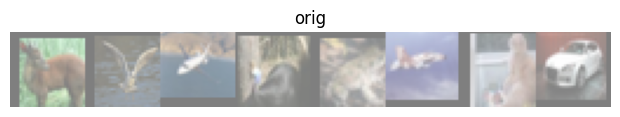

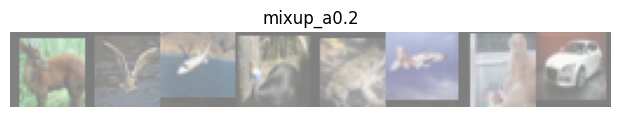


================  WRS_MIXUP | Scenario: LT  ================

--- LT | resnet18 | wrs_mixup ---
Ep 01 | train_loss=2.276 acc=16.4%  val_loss=1.864 acc=29.2%
Ep 05 | train_loss=1.503 acc=31.3%  val_loss=1.311 acc=52.1%
Ep 10 | train_loss=1.047 acc=41.4%  val_loss=0.926 acc=68.2%
Ep 15 | train_loss=0.927 acc=41.8%  val_loss=0.898 acc=69.7%
Ep 20 | train_loss=0.843 acc=50.7%  val_loss=0.755 acc=75.2%
Ep 25 | train_loss=0.615 acc=51.6%  val_loss=0.735 acc=76.0%
Ep 30 | train_loss=0.577 acc=58.1%  val_loss=0.608 acc=80.6%
Ep 35 | train_loss=0.476 acc=49.4%  val_loss=0.560 acc=82.6%
Ep 40 | train_loss=0.463 acc=55.2%  val_loss=0.580 acc=82.3%
Ep 45 | train_loss=0.424 acc=53.5%  val_loss=0.560 acc=83.3%
Ep 50 | train_loss=0.418 acc=53.5%  val_loss=0.552 acc=83.2%
Final test — Acc 83.91% | Macro-F1 84.06% | Balanced Acc 83.91%

--- Classification report: LT | resnet18 | wrs_mixup ---
              precision    recall  f1-score   support

    airplane       0.70      0.95      0.80      1000
 

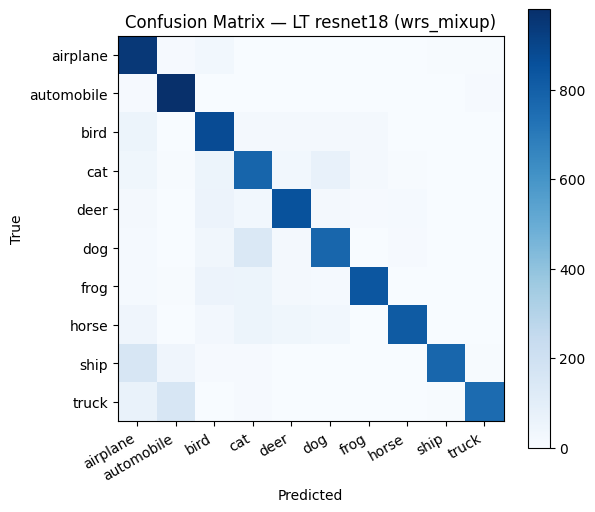

Saved confusion matrix: figures/cm_resnet18_LT_wrs_mixup.png


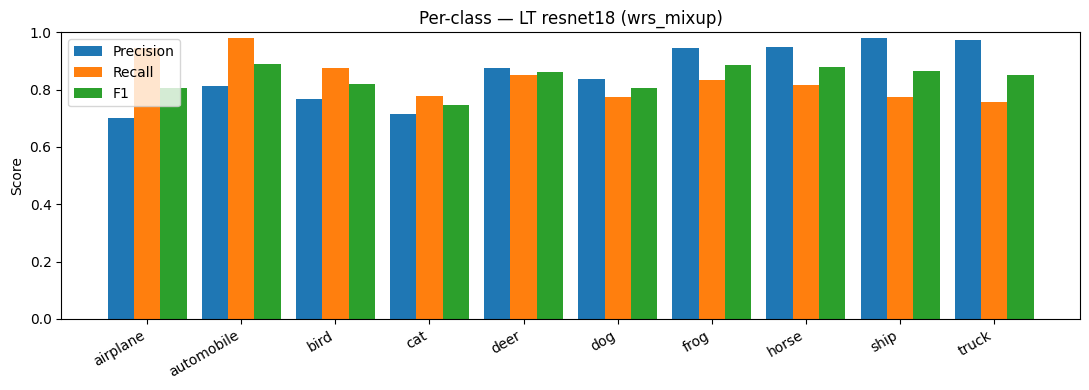

Saved per-class bars: figures/perclass_resnet18_LT_wrs_mixup.png

--- LT | densenet121 | wrs_mixup ---
Ep 01 | train_loss=2.123 acc=21.3%  val_loss=2.337 acc=33.1%
Ep 05 | train_loss=1.405 acc=34.5%  val_loss=1.413 acc=52.5%
Ep 10 | train_loss=1.029 acc=45.8%  val_loss=0.976 acc=66.5%
Ep 15 | train_loss=0.797 acc=49.6%  val_loss=0.829 acc=72.1%
Ep 20 | train_loss=0.696 acc=54.3%  val_loss=0.827 acc=74.1%
Ep 25 | train_loss=0.592 acc=49.4%  val_loss=0.770 acc=76.4%
Ep 30 | train_loss=0.607 acc=50.6%  val_loss=0.592 acc=81.5%
Ep 35 | train_loss=0.428 acc=49.0%  val_loss=0.585 acc=82.6%
Ep 40 | train_loss=0.448 acc=56.1%  val_loss=0.576 acc=82.6%
Ep 45 | train_loss=0.470 acc=50.4%  val_loss=0.566 acc=83.8%
Ep 50 | train_loss=0.437 acc=55.0%  val_loss=0.576 acc=83.6%
Final test — Acc 83.79% | Macro-F1 83.95% | Balanced Acc 83.79%

--- Classification report: LT | densenet121 | wrs_mixup ---
              precision    recall  f1-score   support

    airplane       0.70      0.95      0.81   

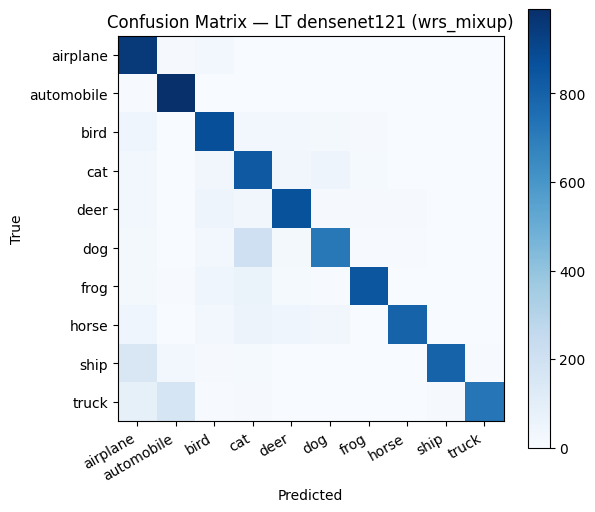

Saved confusion matrix: figures/cm_densenet121_LT_wrs_mixup.png


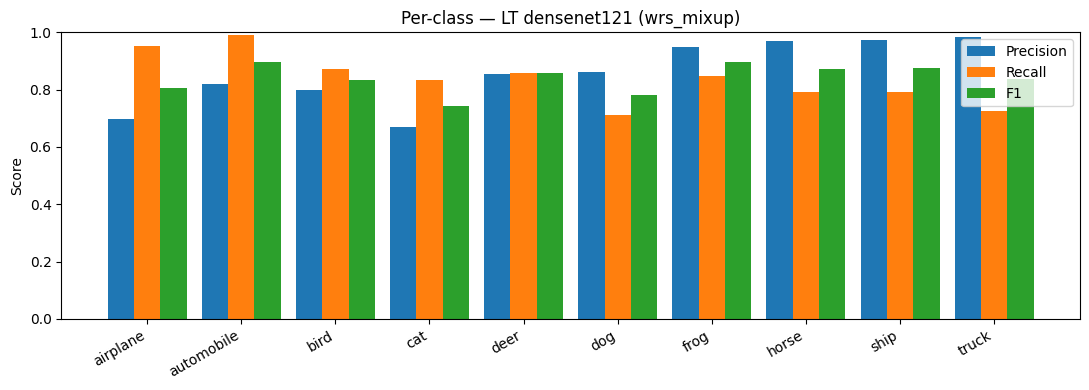

Saved per-class bars: figures/perclass_densenet121_LT_wrs_mixup.png

================  WRS_MIXUP | Scenario: SS  ================

--- SS | resnet18 | wrs_mixup ---
Ep 01 | train_loss=2.158 acc=17.8%  val_loss=1.733 acc=36.2%
Ep 05 | train_loss=1.255 acc=31.3%  val_loss=1.112 acc=61.0%
Ep 10 | train_loss=0.980 acc=43.4%  val_loss=0.763 acc=74.4%
Ep 15 | train_loss=0.768 acc=48.5%  val_loss=0.816 acc=72.8%
Ep 20 | train_loss=0.656 acc=49.8%  val_loss=0.744 acc=75.7%
Ep 25 | train_loss=0.618 acc=53.8%  val_loss=0.598 acc=81.7%
Ep 30 | train_loss=0.563 acc=49.4%  val_loss=0.560 acc=82.7%
Ep 35 | train_loss=0.491 acc=52.8%  val_loss=0.530 acc=84.2%
Ep 40 | train_loss=0.461 acc=57.8%  val_loss=0.451 acc=87.4%
Ep 45 | train_loss=0.383 acc=53.5%  val_loss=0.505 acc=85.7%
Ep 50 | train_loss=0.448 acc=51.6%  val_loss=0.507 acc=85.9%
Final test — Acc 87.35% | Macro-F1 87.40% | Balanced Acc 87.35%

--- Classification report: SS | resnet18 | wrs_mixup ---
              precision    recall  f1-scor

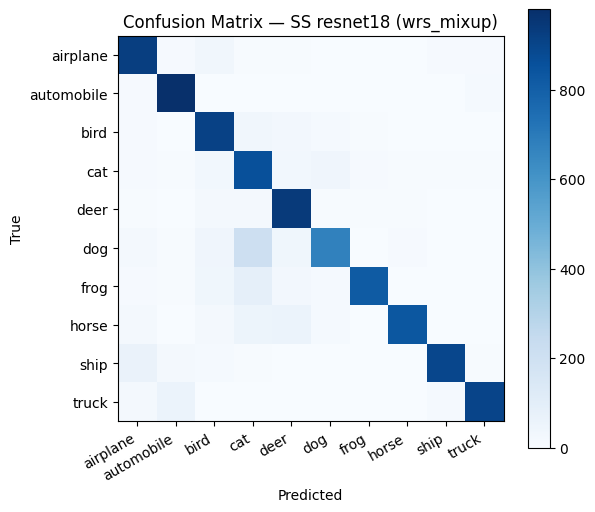

Saved confusion matrix: figures/cm_resnet18_SS_wrs_mixup.png


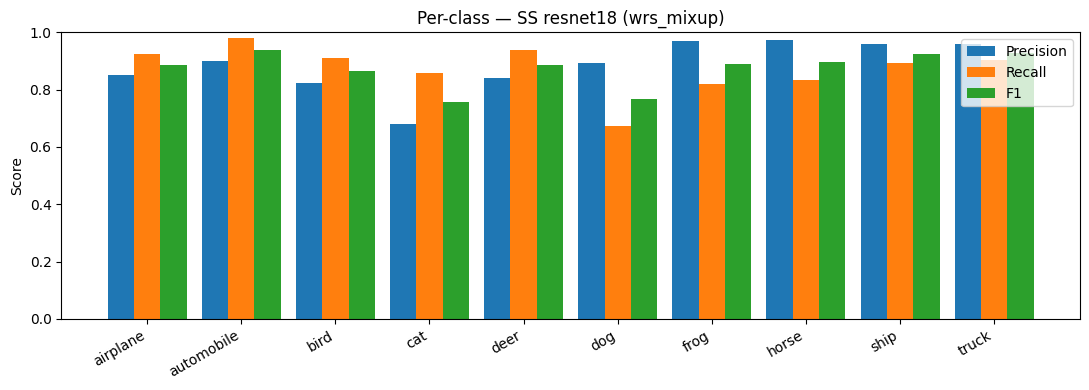

Saved per-class bars: figures/perclass_resnet18_SS_wrs_mixup.png

--- SS | densenet121 | wrs_mixup ---
Ep 01 | train_loss=1.927 acc=23.2%  val_loss=1.538 acc=43.8%
Ep 05 | train_loss=1.157 acc=41.4%  val_loss=1.197 acc=59.2%
Ep 10 | train_loss=0.833 acc=51.7%  val_loss=0.701 acc=77.6%
Ep 15 | train_loss=0.701 acc=44.8%  val_loss=0.703 acc=77.0%
Ep 20 | train_loss=0.631 acc=46.9%  val_loss=0.630 acc=79.5%
Ep 25 | train_loss=0.578 acc=49.8%  val_loss=0.640 acc=80.0%
Ep 30 | train_loss=0.552 acc=56.5%  val_loss=0.517 acc=84.7%
Ep 35 | train_loss=0.492 acc=48.6%  val_loss=0.473 acc=85.9%
Ep 40 | train_loss=0.451 acc=51.6%  val_loss=0.490 acc=86.3%
Ep 45 | train_loss=0.385 acc=52.6%  val_loss=0.498 acc=86.6%
Ep 50 | train_loss=0.379 acc=48.0%  val_loss=0.517 acc=86.6%
Final test — Acc 87.58% | Macro-F1 87.69% | Balanced Acc 87.58%

--- Classification report: SS | densenet121 | wrs_mixup ---
              precision    recall  f1-score   support

    airplane       0.84      0.94      0.89   

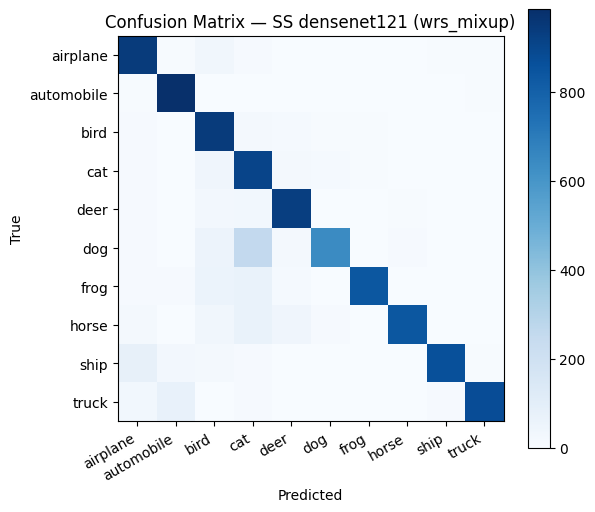

Saved confusion matrix: figures/cm_densenet121_SS_wrs_mixup.png


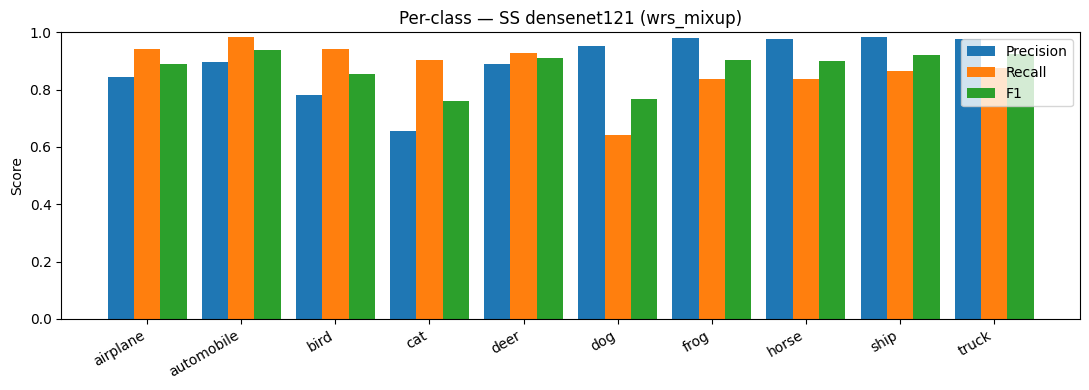

Saved per-class bars: figures/perclass_densenet121_SS_wrs_mixup.png

================  WRS_MIXUP | Scenario: AS  ================

--- AS | resnet18 | wrs_mixup ---
Ep 01 | train_loss=3.049 acc=11.4%  val_loss=2.209 acc=18.6%
Ep 05 | train_loss=1.870 acc=23.5%  val_loss=1.764 acc=33.0%
Ep 10 | train_loss=1.555 acc=28.8%  val_loss=1.449 acc=48.1%
Ep 15 | train_loss=1.282 acc=36.0%  val_loss=1.206 acc=56.8%
Ep 20 | train_loss=1.141 acc=40.9%  val_loss=1.047 acc=63.4%
Ep 25 | train_loss=0.922 acc=46.5%  val_loss=0.999 acc=66.5%
Ep 30 | train_loss=0.777 acc=54.3%  val_loss=0.899 acc=70.4%
Ep 35 | train_loss=0.589 acc=55.6%  val_loss=0.811 acc=73.9%
Ep 40 | train_loss=0.558 acc=48.9%  val_loss=0.721 acc=77.2%
Ep 45 | train_loss=0.547 acc=53.8%  val_loss=0.701 acc=77.9%
Ep 50 | train_loss=0.450 acc=52.2%  val_loss=0.701 acc=77.9%
Final test — Acc 77.95% | Macro-F1 77.93% | Balanced Acc 77.95%

--- Classification report: AS | resnet18 | wrs_mixup ---
              precision    recall  f1-scor

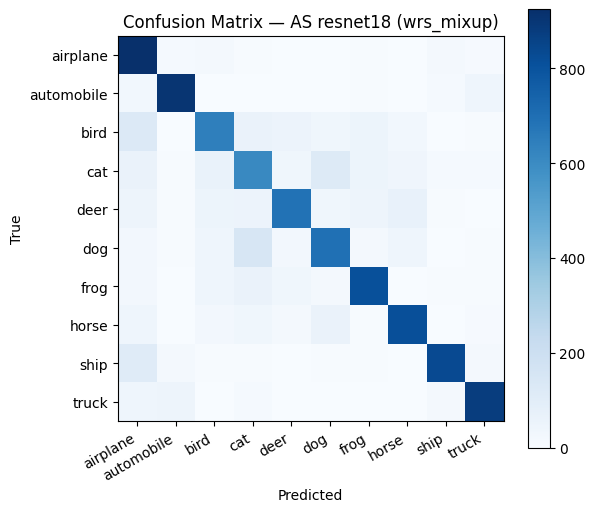

Saved confusion matrix: figures/cm_resnet18_AS_wrs_mixup.png


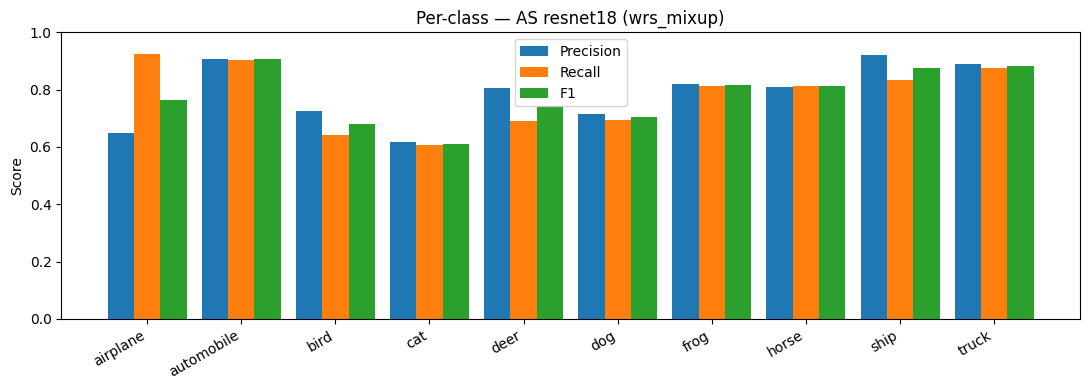

Saved per-class bars: figures/perclass_resnet18_AS_wrs_mixup.png

--- AS | densenet121 | wrs_mixup ---
Ep 01 | train_loss=2.186 acc=16.6%  val_loss=1.835 acc=34.6%
Ep 05 | train_loss=1.444 acc=32.8%  val_loss=1.408 acc=49.5%
Ep 10 | train_loss=1.034 acc=47.0%  val_loss=1.090 acc=62.5%
Ep 15 | train_loss=0.842 acc=46.0%  val_loss=1.266 acc=61.2%
Ep 20 | train_loss=0.734 acc=50.1%  val_loss=1.001 acc=70.5%
Ep 25 | train_loss=0.576 acc=49.1%  val_loss=0.771 acc=76.1%
Ep 30 | train_loss=0.515 acc=52.7%  val_loss=0.874 acc=74.3%
Ep 35 | train_loss=0.476 acc=63.4%  val_loss=0.719 acc=77.6%
Ep 40 | train_loss=0.412 acc=56.7%  val_loss=0.690 acc=79.5%
Ep 45 | train_loss=0.426 acc=53.8%  val_loss=0.682 acc=80.1%
Ep 50 | train_loss=0.392 acc=57.0%  val_loss=0.696 acc=79.9%
Final test — Acc 80.11% | Macro-F1 80.21% | Balanced Acc 80.11%

--- Classification report: AS | densenet121 | wrs_mixup ---
              precision    recall  f1-score   support

    airplane       0.61      0.95      0.75   

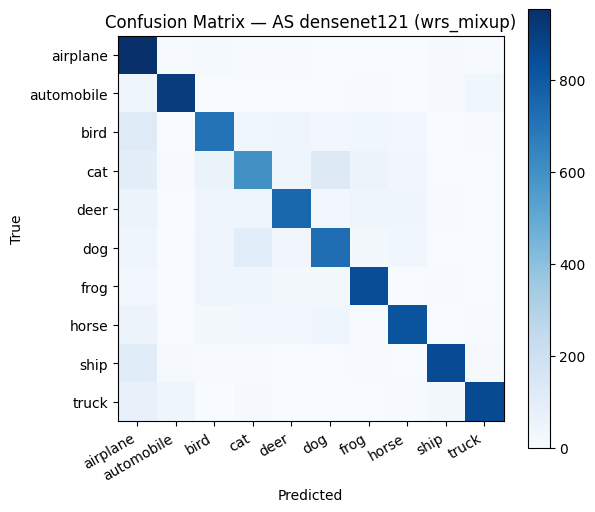

Saved confusion matrix: figures/cm_densenet121_AS_wrs_mixup.png


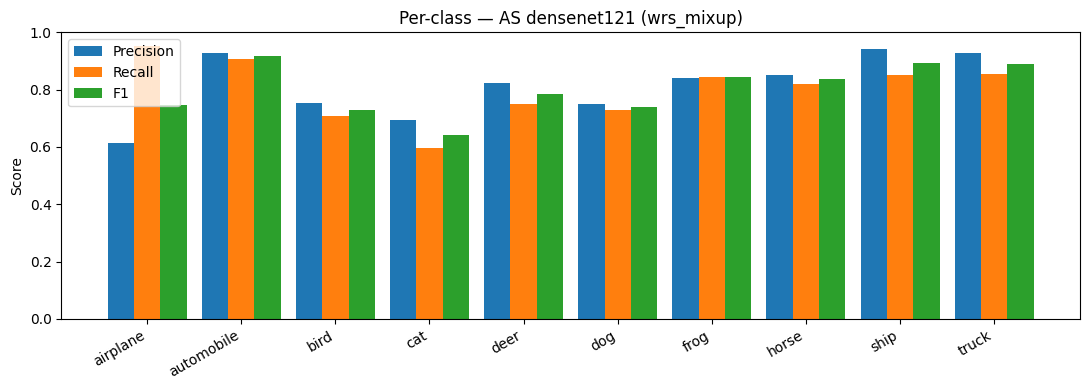

Saved per-class bars: figures/perclass_densenet121_AS_wrs_mixup.png


,Scenario,Model,Macro-F1 (%),Balanced Acc (%),Overall Acc (%)
5,AS,densenet121,80.21,80.11,80.11
4,AS,resnet18,77.93,77.95,77.95
1,LT,densenet121,83.95,83.79,83.79
0,LT,resnet18,84.06,83.91,83.91
3,SS,densenet121,87.69,87.58,87.58
2,SS,resnet18,87.40,87.35,87.35


Saved summary: metrics/summary_wrs_mixup.csv


In [33]:
# Weighted Random Sampler + MixUp
CONFIG.update({"use_mixup": True, "use_cutmix": False, "use_patchmix": False})
run_experiment("wrs_mixup", make_wrs_loader)




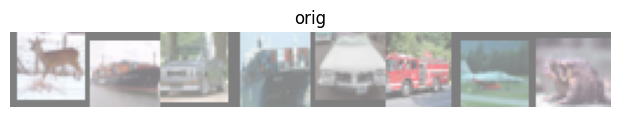

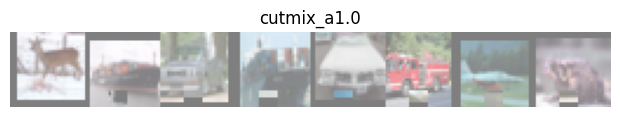


================  WRS_CUTMIX | Scenario: LT  ================

--- LT | resnet18 | wrs_cutmix ---
Ep 01 | train_loss=2.600 acc=13.1%  val_loss=2.089 acc=21.5%
Ep 05 | train_loss=1.994 acc=28.2%  val_loss=1.739 acc=36.8%
Ep 10 | train_loss=1.786 acc=38.1%  val_loss=1.395 acc=49.2%
Ep 15 | train_loss=1.611 acc=45.3%  val_loss=1.270 acc=55.3%
Ep 20 | train_loss=1.509 acc=52.8%  val_loss=1.064 acc=63.2%
Ep 25 | train_loss=1.322 acc=59.9%  val_loss=1.088 acc=65.2%
Ep 30 | train_loss=1.304 acc=58.6%  val_loss=0.811 acc=73.7%
Ep 35 | train_loss=1.134 acc=68.5%  val_loss=0.873 acc=72.3%
Ep 40 | train_loss=1.078 acc=68.0%  val_loss=0.650 acc=79.6%
Ep 45 | train_loss=0.942 acc=74.2%  val_loss=0.600 acc=81.8%
Ep 50 | train_loss=0.955 acc=75.1%  val_loss=0.597 acc=81.8%
Final test — Acc 82.14% | Macro-F1 82.28% | Balanced Acc 82.14%

--- Classification report: LT | resnet18 | wrs_cutmix ---
              precision    recall  f1-score   support

    airplane       0.74      0.91      0.82      100

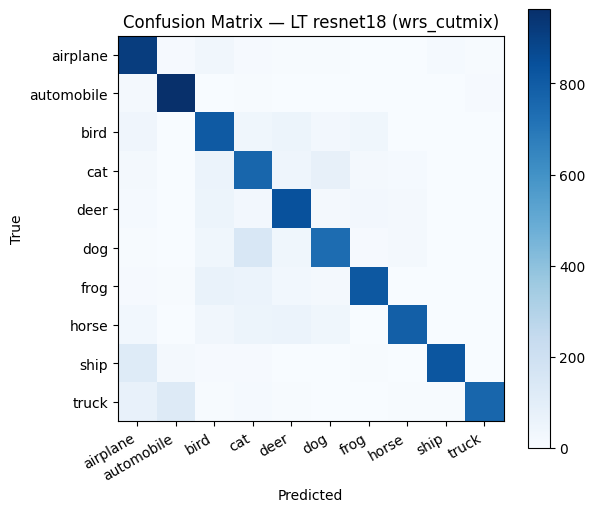

Saved confusion matrix: figures/cm_resnet18_LT_wrs_cutmix.png


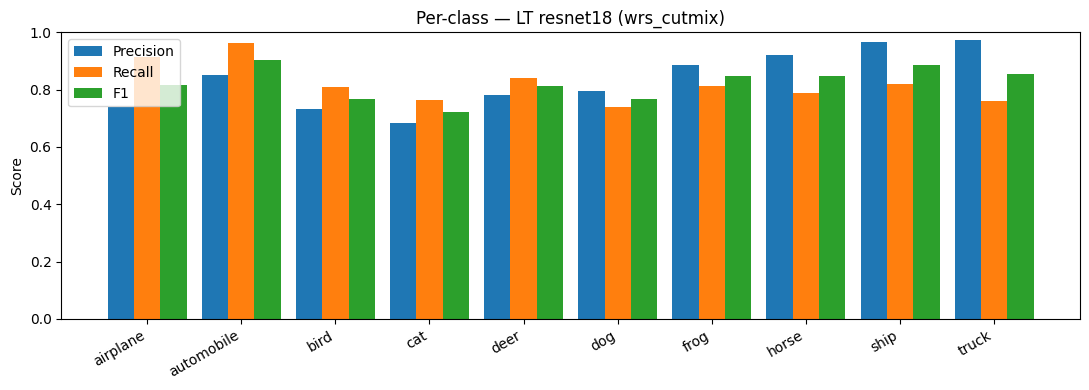

Saved per-class bars: figures/perclass_resnet18_LT_wrs_cutmix.png

--- LT | densenet121 | wrs_cutmix ---
Ep 01 | train_loss=2.202 acc=21.6%  val_loss=1.840 acc=30.6%
Ep 05 | train_loss=1.748 acc=40.4%  val_loss=1.468 acc=50.1%
Ep 10 | train_loss=1.524 acc=51.0%  val_loss=1.193 acc=58.5%
Ep 15 | train_loss=1.420 acc=54.5%  val_loss=1.050 acc=63.8%
Ep 20 | train_loss=1.268 acc=61.5%  val_loss=0.918 acc=68.6%
Ep 25 | train_loss=1.254 acc=61.9%  val_loss=0.860 acc=71.2%
Ep 30 | train_loss=1.092 acc=68.4%  val_loss=0.771 acc=75.1%
Ep 35 | train_loss=1.031 acc=68.5%  val_loss=0.714 acc=78.0%
Ep 40 | train_loss=0.928 acc=73.1%  val_loss=0.593 acc=82.0%
Ep 45 | train_loss=0.845 acc=78.9%  val_loss=0.609 acc=81.3%
Ep 50 | train_loss=0.821 acc=77.1%  val_loss=0.613 acc=81.6%
Final test — Acc 82.62% | Macro-F1 82.73% | Balanced Acc 82.62%

--- Classification report: LT | densenet121 | wrs_cutmix ---
              precision    recall  f1-score   support

    airplane       0.73      0.93      0.82

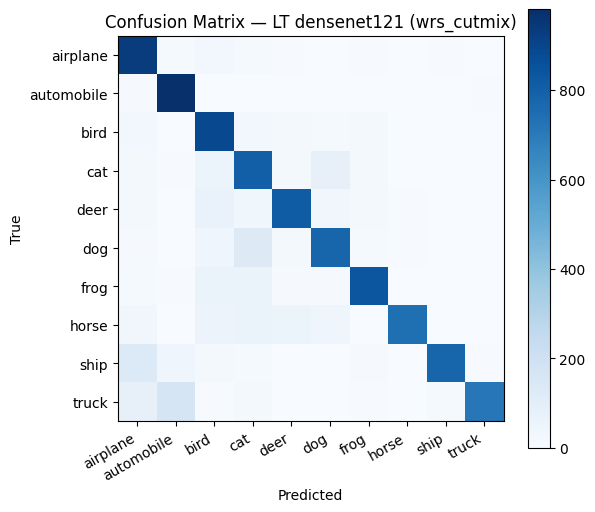

Saved confusion matrix: figures/cm_densenet121_LT_wrs_cutmix.png


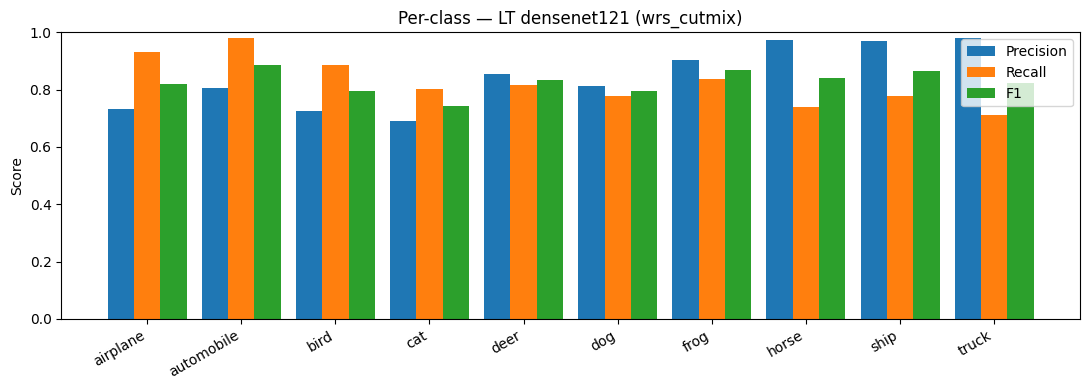

Saved per-class bars: figures/perclass_densenet121_LT_wrs_cutmix.png

================  WRS_CUTMIX | Scenario: SS  ================

--- SS | resnet18 | wrs_cutmix ---
Ep 01 | train_loss=2.361 acc=16.5%  val_loss=1.850 acc=30.3%
Ep 05 | train_loss=1.779 acc=39.0%  val_loss=1.436 acc=49.5%
Ep 10 | train_loss=1.522 acc=51.4%  val_loss=1.001 acc=65.2%
Ep 15 | train_loss=1.384 acc=55.4%  val_loss=0.944 acc=68.3%
Ep 20 | train_loss=1.266 acc=60.4%  val_loss=0.750 acc=75.9%
Ep 25 | train_loss=1.158 acc=66.0%  val_loss=0.791 acc=75.0%
Ep 30 | train_loss=1.090 acc=66.7%  val_loss=0.643 acc=80.7%
Ep 35 | train_loss=1.007 acc=70.4%  val_loss=0.610 acc=81.4%
Ep 40 | train_loss=0.894 acc=74.8%  val_loss=0.598 acc=82.6%
Ep 45 | train_loss=0.841 acc=74.5%  val_loss=0.493 acc=85.7%
Ep 50 | train_loss=0.834 acc=75.4%  val_loss=0.497 acc=85.8%
Final test — Acc 86.08% | Macro-F1 86.10% | Balanced Acc 86.08%

--- Classification report: SS | resnet18 | wrs_cutmix ---
              precision    recall  f1-

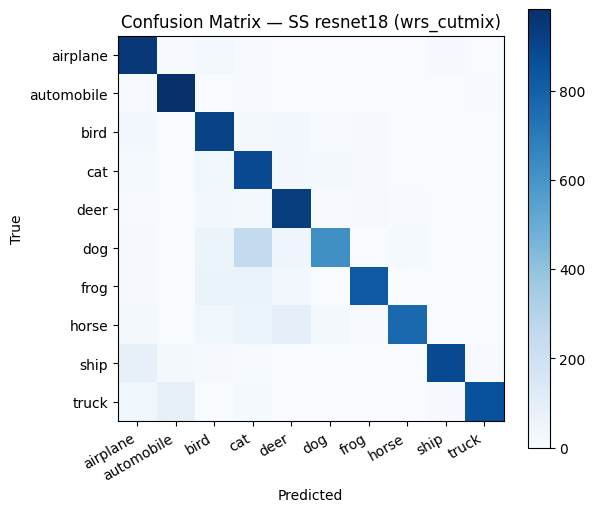

Saved confusion matrix: figures/cm_resnet18_SS_wrs_cutmix.png


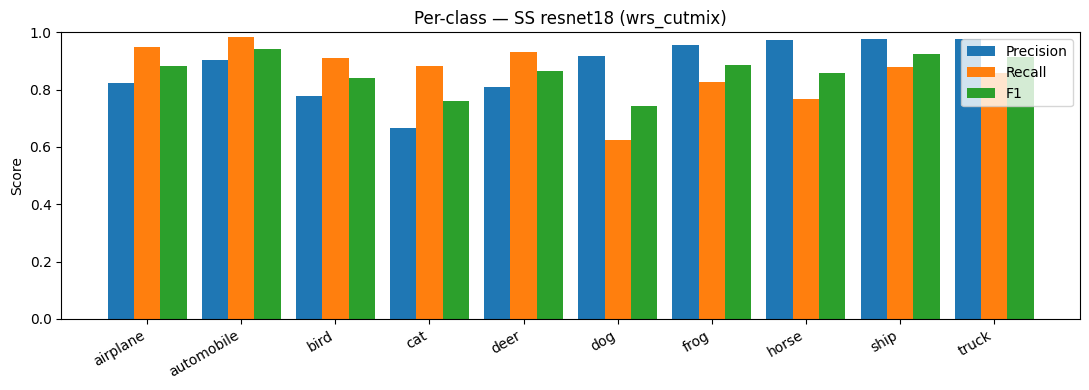

Saved per-class bars: figures/perclass_resnet18_SS_wrs_cutmix.png

--- SS | densenet121 | wrs_cutmix ---
Ep 01 | train_loss=2.112 acc=24.9%  val_loss=1.608 acc=41.0%
Ep 05 | train_loss=1.581 acc=48.5%  val_loss=1.152 acc=60.6%
Ep 10 | train_loss=1.394 acc=56.0%  val_loss=0.958 acc=67.7%
Ep 15 | train_loss=1.204 acc=65.6%  val_loss=0.692 acc=78.1%
Ep 20 | train_loss=1.124 acc=66.1%  val_loss=0.707 acc=78.2%
Ep 25 | train_loss=1.088 acc=68.8%  val_loss=0.682 acc=78.6%
Ep 30 | train_loss=0.969 acc=68.9%  val_loss=0.639 acc=81.5%
Ep 35 | train_loss=0.844 acc=75.4%  val_loss=0.581 acc=82.8%
Ep 40 | train_loss=0.774 acc=80.1%  val_loss=0.579 acc=82.9%
Ep 45 | train_loss=0.720 acc=80.8%  val_loss=0.573 acc=83.5%
Ep 50 | train_loss=0.692 acc=80.0%  val_loss=0.557 acc=84.3%
Final test — Acc 85.88% | Macro-F1 85.80% | Balanced Acc 85.88%

--- Classification report: SS | densenet121 | wrs_cutmix ---
              precision    recall  f1-score   support

    airplane       0.84      0.94      0.89

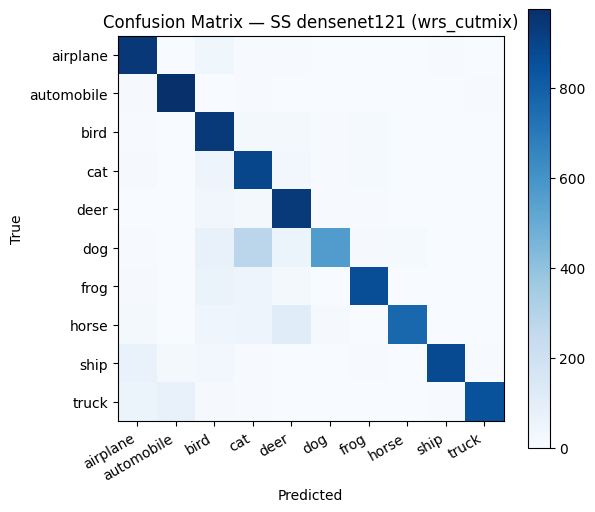

Saved confusion matrix: figures/cm_densenet121_SS_wrs_cutmix.png


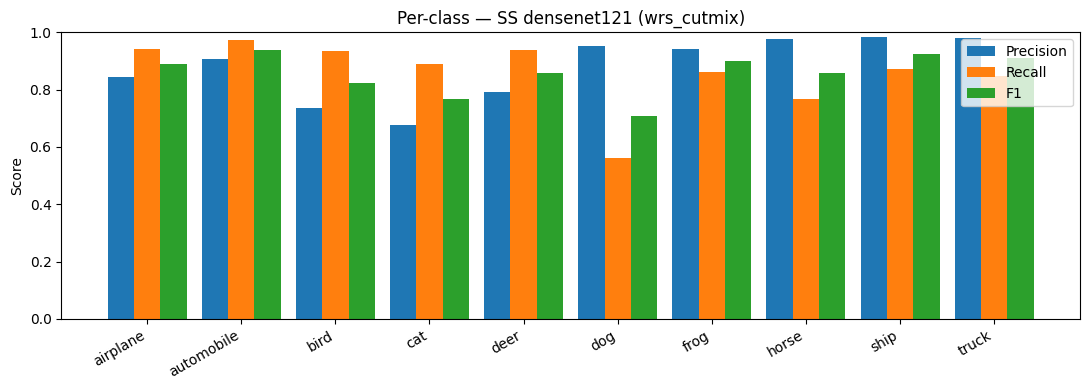

Saved per-class bars: figures/perclass_densenet121_SS_wrs_cutmix.png

================  WRS_CUTMIX | Scenario: AS  ================

--- AS | resnet18 | wrs_cutmix ---
Ep 01 | train_loss=2.721 acc=13.2%  val_loss=2.127 acc=20.1%
Ep 05 | train_loss=1.996 acc=28.3%  val_loss=1.646 acc=38.8%
Ep 10 | train_loss=1.835 acc=36.3%  val_loss=1.452 acc=46.9%
Ep 15 | train_loss=1.721 acc=40.8%  val_loss=1.236 acc=56.6%
Ep 20 | train_loss=1.617 acc=47.4%  val_loss=1.084 acc=62.4%
Ep 25 | train_loss=1.519 acc=51.1%  val_loss=1.122 acc=61.1%
Ep 30 | train_loss=1.443 acc=54.2%  val_loss=0.951 acc=68.2%
Ep 35 | train_loss=1.249 acc=64.0%  val_loss=0.807 acc=72.7%
Ep 40 | train_loss=1.193 acc=63.3%  val_loss=0.744 acc=75.3%
Ep 45 | train_loss=1.227 acc=59.3%  val_loss=0.723 acc=76.7%
Ep 50 | train_loss=1.170 acc=62.5%  val_loss=0.708 acc=77.6%
Final test — Acc 77.64% | Macro-F1 77.51% | Balanced Acc 77.64%

--- Classification report: AS | resnet18 | wrs_cutmix ---
              precision    recall  f1-

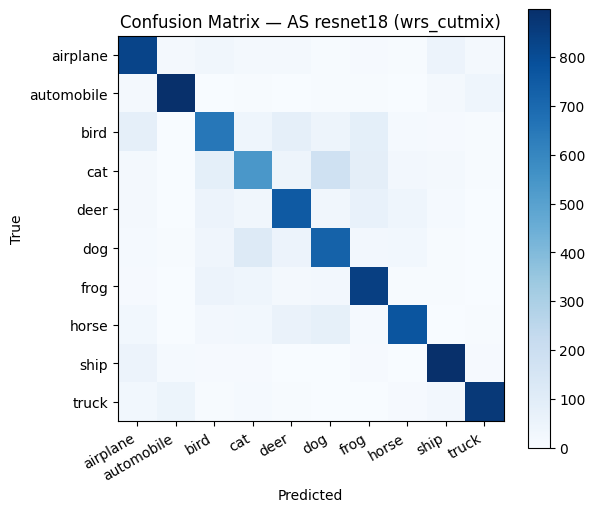

Saved confusion matrix: figures/cm_resnet18_AS_wrs_cutmix.png


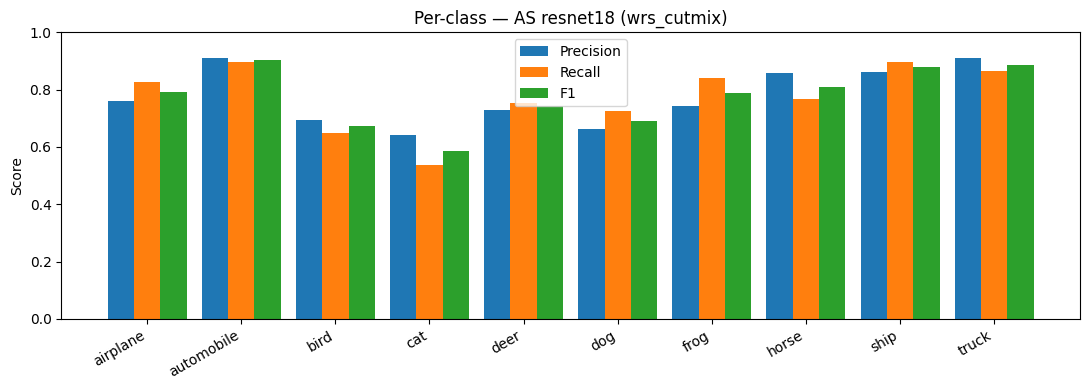

Saved per-class bars: figures/perclass_resnet18_AS_wrs_cutmix.png

--- AS | densenet121 | wrs_cutmix ---
Ep 01 | train_loss=2.431 acc=16.8%  val_loss=1.940 acc=25.1%
Ep 05 | train_loss=1.887 acc=36.1%  val_loss=1.632 acc=39.0%
Ep 10 | train_loss=1.707 acc=42.8%  val_loss=1.349 acc=53.7%
Ep 15 | train_loss=1.520 acc=50.1%  val_loss=1.251 acc=57.3%
Ep 20 | train_loss=1.472 acc=53.3%  val_loss=1.047 acc=64.4%
Ep 25 | train_loss=1.347 acc=60.1%  val_loss=0.973 acc=66.6%
Ep 30 | train_loss=1.227 acc=65.6%  val_loss=0.918 acc=69.7%
Ep 35 | train_loss=1.150 acc=67.5%  val_loss=0.848 acc=72.5%
Ep 40 | train_loss=1.014 acc=69.2%  val_loss=0.808 acc=74.9%
Ep 45 | train_loss=1.020 acc=69.5%  val_loss=0.751 acc=76.6%
Ep 50 | train_loss=0.977 acc=68.6%  val_loss=0.731 acc=77.2%
Final test — Acc 77.16% | Macro-F1 77.19% | Balanced Acc 77.16%

--- Classification report: AS | densenet121 | wrs_cutmix ---
              precision    recall  f1-score   support

    airplane       0.69      0.90      0.78

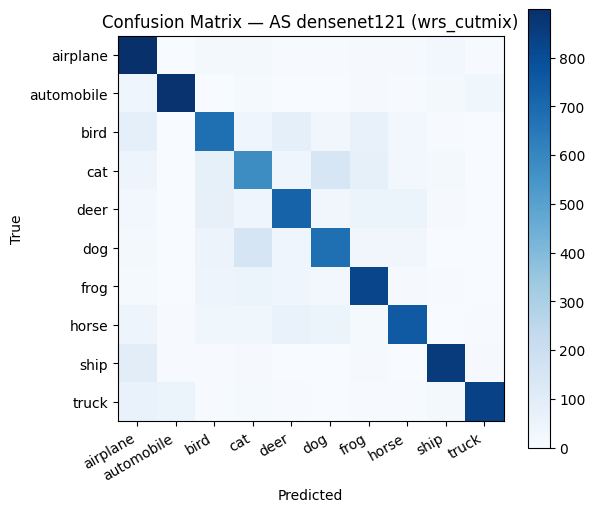

Saved confusion matrix: figures/cm_densenet121_AS_wrs_cutmix.png


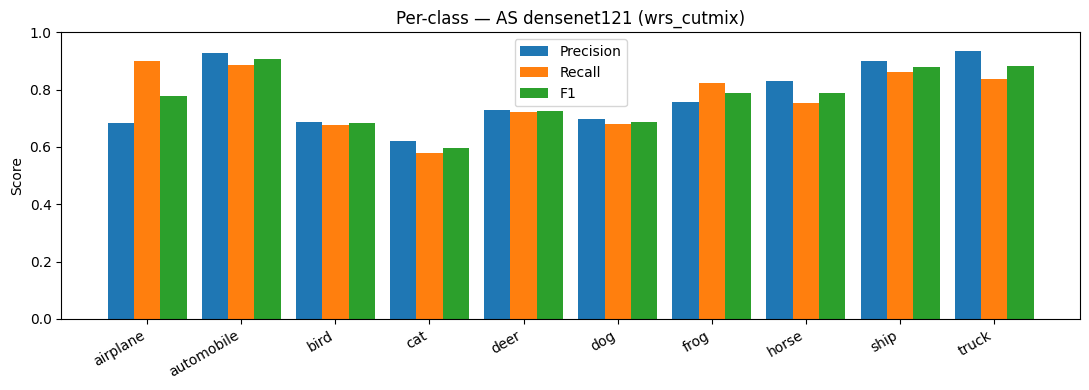

Saved per-class bars: figures/perclass_densenet121_AS_wrs_cutmix.png


,Scenario,Model,Macro-F1 (%),Balanced Acc (%),Overall Acc (%)
5,AS,densenet121,77.19,77.16,77.16
4,AS,resnet18,77.51,77.64,77.64
1,LT,densenet121,82.73,82.62,82.62
0,LT,resnet18,82.28,82.14,82.14
3,SS,densenet121,85.80,85.88,85.88
2,SS,resnet18,86.10,86.08,86.08


Saved summary: metrics/summary_wrs_cutmix.csv


In [34]:
# Weighted Random Sampler + CutMix
CONFIG.update({"use_mixup": False, "use_cutmix": True, "use_patchmix": False})
run_experiment("wrs_cutmix", make_wrs_loader)



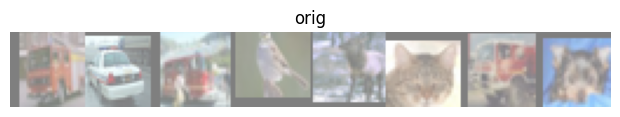

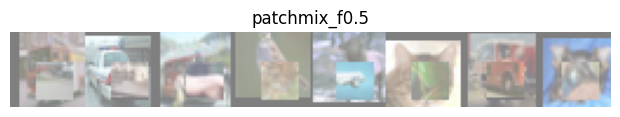


================  WRS_PATCHMIX | Scenario: LT  ================

--- LT | resnet18 | wrs_patchmix ---
Ep 01 | train_loss=2.700 acc=15.2%  val_loss=2.091 acc=19.3%
Ep 05 | train_loss=2.111 acc=24.6%  val_loss=1.742 acc=35.4%
Ep 10 | train_loss=1.995 acc=33.4%  val_loss=1.630 acc=41.9%
Ep 15 | train_loss=1.898 acc=37.7%  val_loss=1.515 acc=45.7%
Ep 20 | train_loss=1.794 acc=42.8%  val_loss=1.304 acc=54.9%
Ep 25 | train_loss=1.710 acc=45.4%  val_loss=1.193 acc=59.3%
Ep 30 | train_loss=1.615 acc=49.4%  val_loss=1.099 acc=63.6%
Ep 35 | train_loss=1.536 acc=51.8%  val_loss=0.918 acc=71.2%
Ep 40 | train_loss=1.428 acc=54.1%  val_loss=0.807 acc=75.8%
Ep 45 | train_loss=1.328 acc=56.1%  val_loss=0.774 acc=76.4%
Ep 50 | train_loss=1.292 acc=58.4%  val_loss=0.712 acc=78.6%
Final test — Acc 78.58% | Macro-F1 78.53% | Balanced Acc 78.58%

--- Classification report: LT | resnet18 | wrs_patchmix ---
              precision    recall  f1-score   support

    airplane       0.71      0.86      0.78   

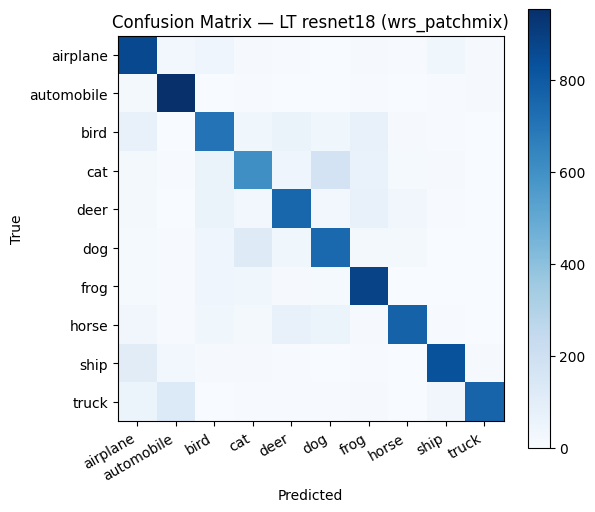

Saved confusion matrix: figures/cm_resnet18_LT_wrs_patchmix.png


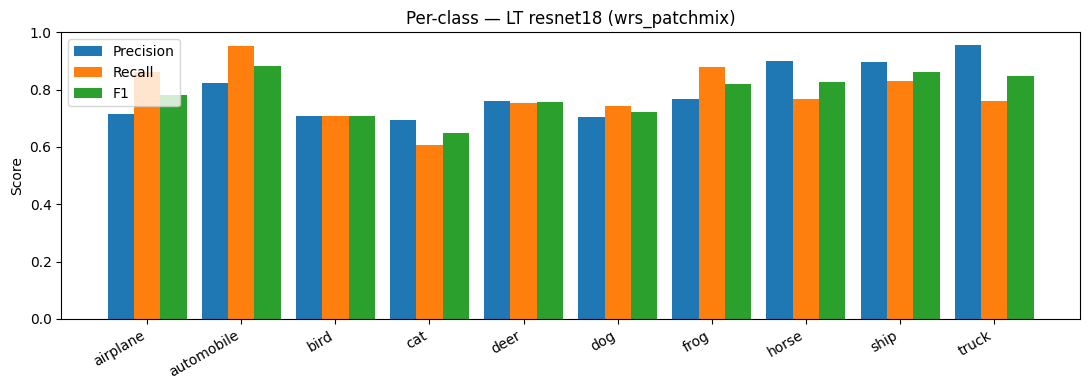

Saved per-class bars: figures/perclass_resnet18_LT_wrs_patchmix.png

--- LT | densenet121 | wrs_patchmix ---
Ep 01 | train_loss=2.263 acc=22.2%  val_loss=1.844 acc=34.8%
Ep 05 | train_loss=1.961 acc=36.6%  val_loss=1.579 acc=43.9%
Ep 10 | train_loss=1.782 acc=44.2%  val_loss=1.342 acc=55.8%
Ep 15 | train_loss=1.658 acc=48.3%  val_loss=1.171 acc=59.2%
Ep 20 | train_loss=1.551 acc=53.6%  val_loss=1.045 acc=67.0%
Ep 25 | train_loss=1.438 acc=54.8%  val_loss=0.905 acc=69.5%
Ep 30 | train_loss=1.351 acc=57.4%  val_loss=0.741 acc=78.5%
Ep 35 | train_loss=1.241 acc=58.5%  val_loss=0.720 acc=77.2%
Ep 40 | train_loss=1.129 acc=60.2%  val_loss=0.585 acc=82.5%
Ep 45 | train_loss=1.037 acc=63.0%  val_loss=0.570 acc=82.9%
Ep 50 | train_loss=0.990 acc=63.2%  val_loss=0.555 acc=83.5%
Final test — Acc 84.08% | Macro-F1 84.13% | Balanced Acc 84.08%

--- Classification report: LT | densenet121 | wrs_patchmix ---
              precision    recall  f1-score   support

    airplane       0.77      0.94    

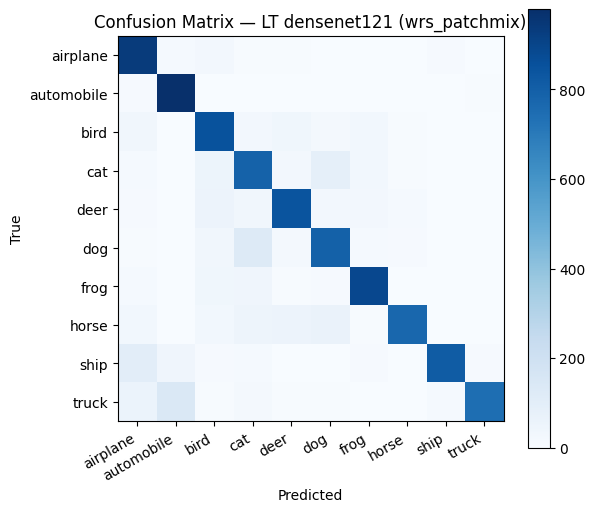

Saved confusion matrix: figures/cm_densenet121_LT_wrs_patchmix.png


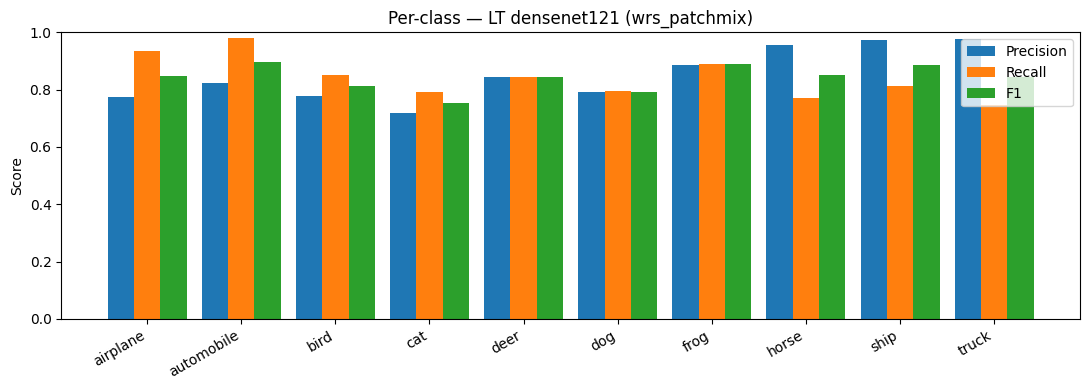

Saved per-class bars: figures/perclass_densenet121_LT_wrs_patchmix.png

================  WRS_PATCHMIX | Scenario: SS  ================

--- SS | resnet18 | wrs_patchmix ---
Ep 01 | train_loss=2.550 acc=14.5%  val_loss=2.065 acc=21.0%
Ep 05 | train_loss=2.052 acc=29.7%  val_loss=1.684 acc=39.3%
Ep 10 | train_loss=1.867 acc=40.3%  val_loss=1.463 acc=45.8%
Ep 15 | train_loss=1.724 acc=45.9%  val_loss=1.419 acc=52.6%
Ep 20 | train_loss=1.603 acc=49.6%  val_loss=1.007 acc=65.4%
Ep 25 | train_loss=1.494 acc=52.2%  val_loss=0.895 acc=70.4%
Ep 30 | train_loss=1.393 acc=55.2%  val_loss=0.812 acc=74.1%
Ep 35 | train_loss=1.295 acc=57.7%  val_loss=0.693 acc=78.6%
Ep 40 | train_loss=1.176 acc=61.3%  val_loss=0.535 acc=84.0%
Ep 45 | train_loss=1.077 acc=64.0%  val_loss=0.503 acc=85.2%
Ep 50 | train_loss=1.035 acc=64.6%  val_loss=0.476 acc=86.1%
Final test — Acc 86.61% | Macro-F1 86.62% | Balanced Acc 86.61%

--- Classification report: SS | resnet18 | wrs_patchmix ---
              precision    rec

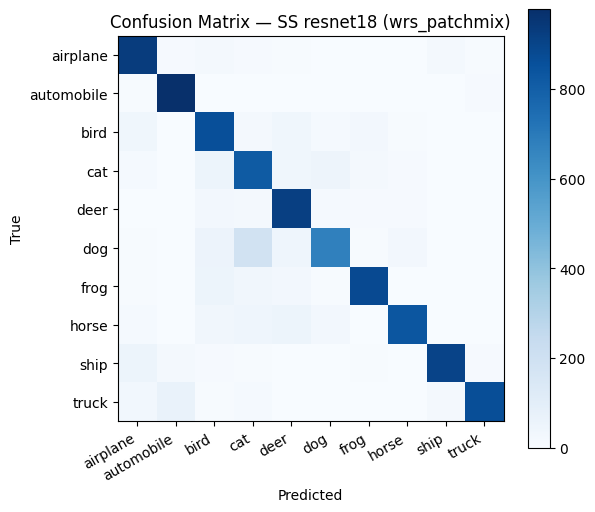

Saved confusion matrix: figures/cm_resnet18_SS_wrs_patchmix.png


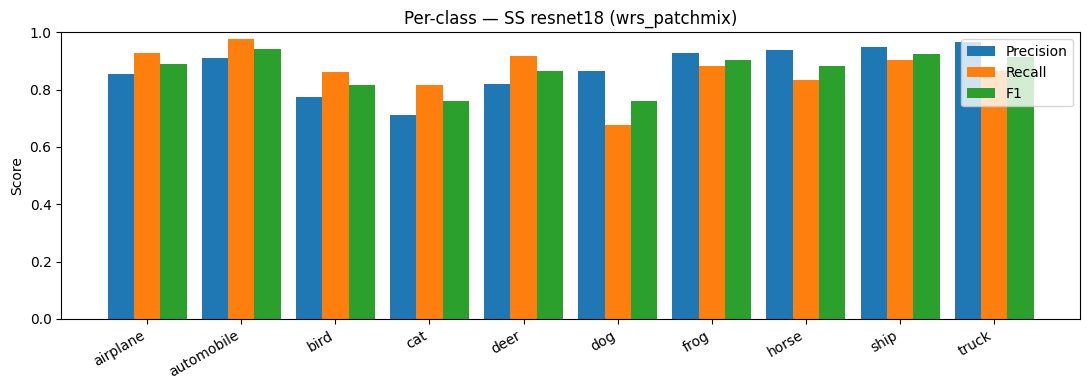

Saved per-class bars: figures/perclass_resnet18_SS_wrs_patchmix.png

--- SS | densenet121 | wrs_patchmix ---
Ep 01 | train_loss=2.216 acc=24.7%  val_loss=1.668 acc=39.9%
Ep 05 | train_loss=1.881 acc=41.4%  val_loss=1.354 acc=52.1%
Ep 10 | train_loss=1.693 acc=48.9%  val_loss=1.123 acc=62.9%
Ep 15 | train_loss=1.543 acc=53.0%  val_loss=0.913 acc=71.5%
Ep 20 | train_loss=1.427 acc=54.0%  val_loss=0.850 acc=72.4%
Ep 25 | train_loss=1.339 acc=57.1%  val_loss=0.781 acc=75.8%
Ep 30 | train_loss=1.228 acc=59.7%  val_loss=0.603 acc=81.0%
Ep 35 | train_loss=1.129 acc=61.8%  val_loss=0.560 acc=83.6%
Ep 40 | train_loss=1.014 acc=64.6%  val_loss=0.466 acc=85.9%
Ep 45 | train_loss=0.922 acc=65.5%  val_loss=0.514 acc=85.1%
Ep 50 | train_loss=0.876 acc=65.8%  val_loss=0.544 acc=84.1%
Final test — Acc 85.94% | Macro-F1 86.06% | Balanced Acc 85.94%

--- Classification report: SS | densenet121 | wrs_patchmix ---
              precision    recall  f1-score   support

    airplane       0.83      0.94    

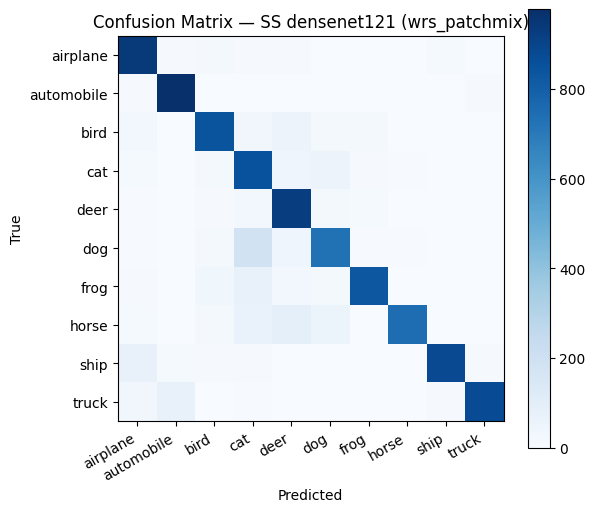

Saved confusion matrix: figures/cm_densenet121_SS_wrs_patchmix.png


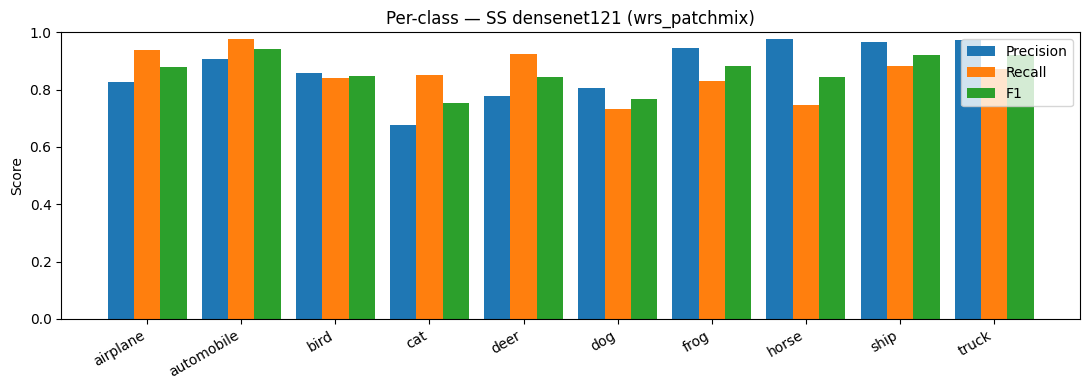

Saved per-class bars: figures/perclass_densenet121_SS_wrs_patchmix.png

================  WRS_PATCHMIX | Scenario: AS  ================

--- AS | resnet18 | wrs_patchmix ---
Ep 01 | train_loss=3.047 acc=9.5%  val_loss=2.312 acc=10.2%
Ep 05 | train_loss=2.290 acc=12.7%  val_loss=2.261 acc=14.3%
Ep 10 | train_loss=2.145 acc=22.0%  val_loss=1.849 acc=28.1%
Ep 15 | train_loss=2.060 acc=26.8%  val_loss=1.743 acc=34.1%
Ep 20 | train_loss=1.988 acc=34.7%  val_loss=1.549 acc=43.8%
Ep 25 | train_loss=1.911 acc=37.2%  val_loss=1.441 acc=49.1%
Ep 30 | train_loss=1.832 acc=41.2%  val_loss=1.263 acc=57.9%
Ep 35 | train_loss=1.770 acc=44.2%  val_loss=1.247 acc=57.3%
Ep 40 | train_loss=1.684 acc=48.2%  val_loss=1.046 acc=66.5%
Ep 45 | train_loss=1.619 acc=50.6%  val_loss=0.966 acc=69.2%
Ep 50 | train_loss=1.594 acc=50.9%  val_loss=0.950 acc=69.9%
Final test — Acc 69.95% | Macro-F1 69.38% | Balanced Acc 69.95%

--- Classification report: AS | resnet18 | wrs_patchmix ---
              precision    reca

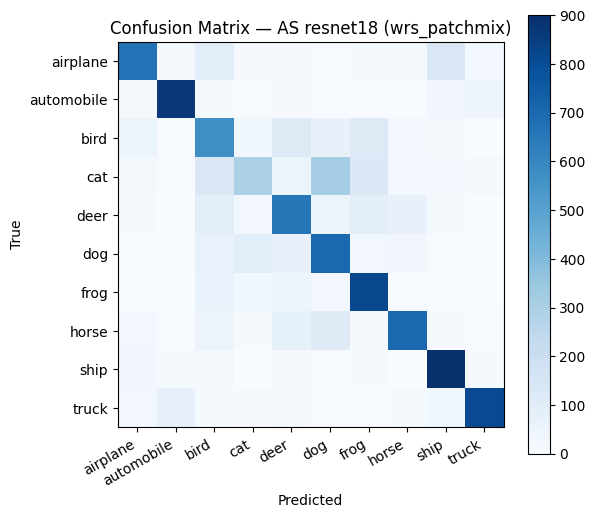

Saved confusion matrix: figures/cm_resnet18_AS_wrs_patchmix.png


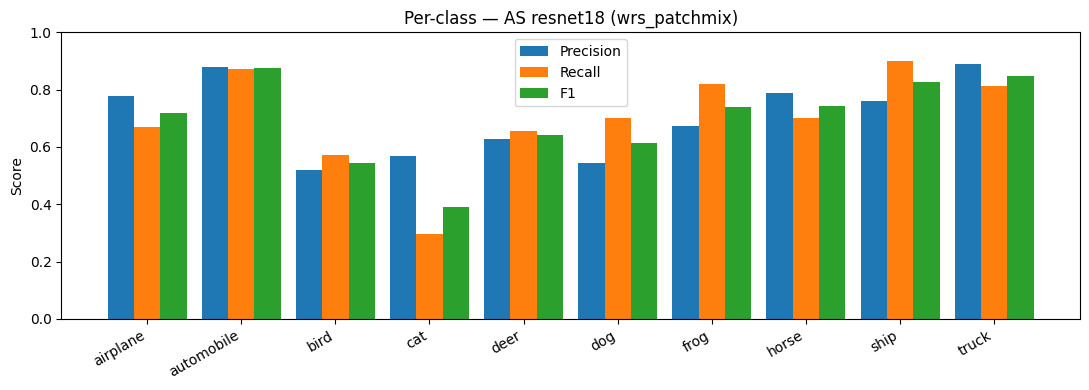

Saved per-class bars: figures/perclass_resnet18_AS_wrs_patchmix.png

--- AS | densenet121 | wrs_patchmix ---
Ep 01 | train_loss=2.424 acc=19.4%  val_loss=1.986 acc=24.5%
Ep 05 | train_loss=2.032 acc=32.8%  val_loss=1.816 acc=34.9%
Ep 10 | train_loss=1.937 acc=37.6%  val_loss=1.471 acc=46.8%
Ep 15 | train_loss=1.834 acc=41.9%  val_loss=1.290 acc=57.5%
Ep 20 | train_loss=1.759 acc=46.4%  val_loss=1.165 acc=60.4%
Ep 25 | train_loss=1.663 acc=50.0%  val_loss=1.067 acc=65.9%
Ep 30 | train_loss=1.591 acc=51.6%  val_loss=0.955 acc=69.7%
Ep 35 | train_loss=1.478 acc=55.0%  val_loss=0.930 acc=70.2%
Ep 40 | train_loss=1.381 acc=56.2%  val_loss=0.815 acc=74.2%
Ep 45 | train_loss=1.300 acc=59.8%  val_loss=0.734 acc=79.1%
Ep 50 | train_loss=1.262 acc=59.9%  val_loss=0.714 acc=79.3%
Final test — Acc 79.38% | Macro-F1 79.22% | Balanced Acc 79.38%

--- Classification report: AS | densenet121 | wrs_patchmix ---
              precision    recall  f1-score   support

    airplane       0.80      0.82    

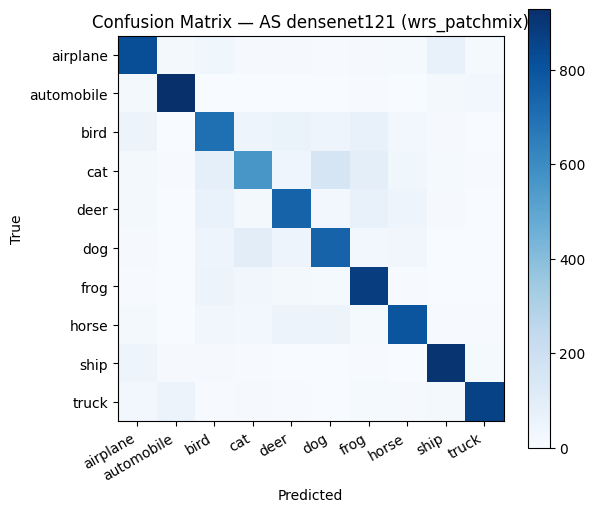

Saved confusion matrix: figures/cm_densenet121_AS_wrs_patchmix.png


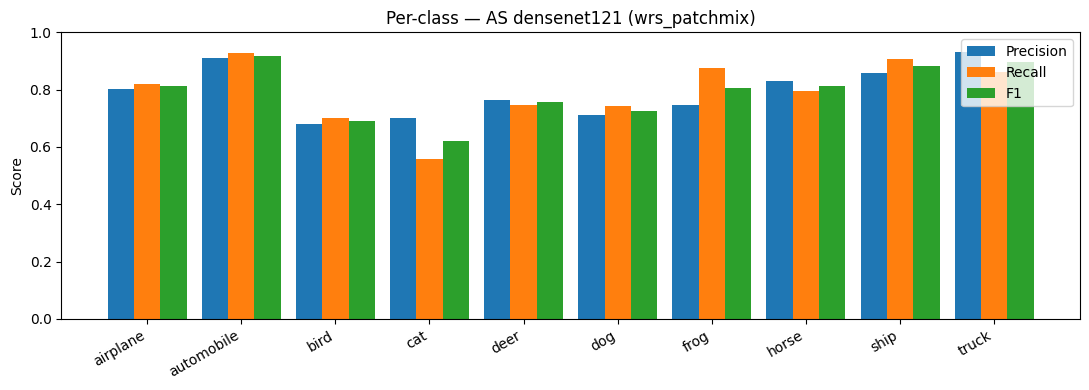

Saved per-class bars: figures/perclass_densenet121_AS_wrs_patchmix.png


,Scenario,Model,Macro-F1 (%),Balanced Acc (%),Overall Acc (%)
5,AS,densenet121,79.22,79.38,79.38
4,AS,resnet18,69.38,69.95,69.95
1,LT,densenet121,84.13,84.08,84.08
0,LT,resnet18,78.53,78.58,78.58
3,SS,densenet121,86.06,85.94,85.94
2,SS,resnet18,86.62,86.61,86.61


Saved summary: metrics/summary_wrs_patchmix.csv


In [35]:

#  Weighted Random Sampler + PatchMix
CONFIG.update({"use_mixup": False, "use_cutmix": False, "use_patchmix": True})
run_experiment("wrs_patchmix", make_wrs_loader)



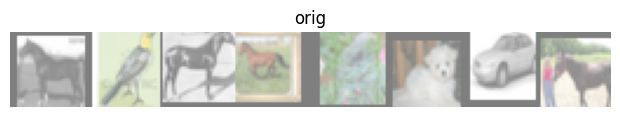

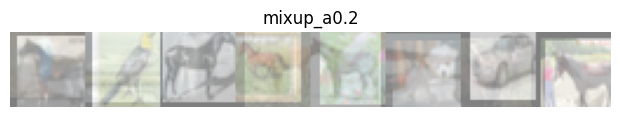


================  ROS_MIXUP | Scenario: LT  ================

--- LT | resnet18 | ros_mixup ---
Ep 01 | train_loss=2.060 acc=19.8%  val_loss=1.653 acc=40.1%
Ep 05 | train_loss=1.010 acc=41.7%  val_loss=0.852 acc=72.5%
Ep 10 | train_loss=0.748 acc=48.1%  val_loss=0.834 acc=73.0%
Ep 15 | train_loss=0.576 acc=51.8%  val_loss=0.664 acc=79.1%
Ep 20 | train_loss=0.553 acc=53.0%  val_loss=0.652 acc=79.9%
Ep 25 | train_loss=0.502 acc=51.1%  val_loss=0.733 acc=77.3%
Ep 30 | train_loss=0.508 acc=52.1%  val_loss=0.527 acc=84.2%
Ep 35 | train_loss=0.488 acc=56.8%  val_loss=0.560 acc=83.6%
Ep 40 | train_loss=0.424 acc=54.7%  val_loss=0.505 acc=85.5%
Ep 45 | train_loss=0.401 acc=50.6%  val_loss=0.486 acc=86.4%
Ep 50 | train_loss=0.383 acc=58.5%  val_loss=0.461 acc=86.7%
Final test — Acc 87.37% | Macro-F1 87.44% | Balanced Acc 87.37%

--- Classification report: LT | resnet18 | ros_mixup ---
              precision    recall  f1-score   support

    airplane       0.79      0.95      0.86      1000
 

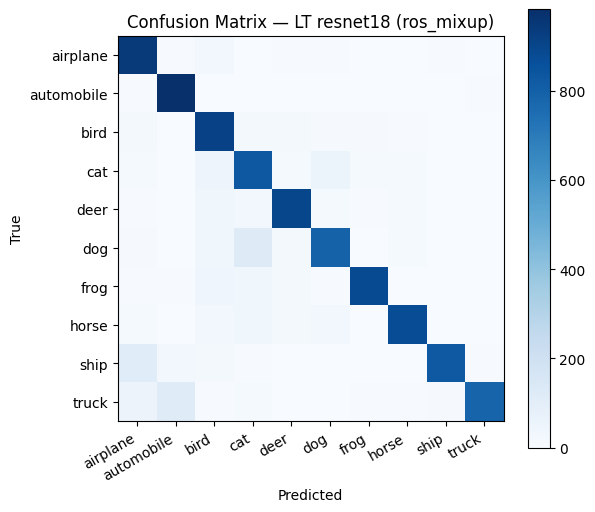

Saved confusion matrix: figures/cm_resnet18_LT_ros_mixup.png


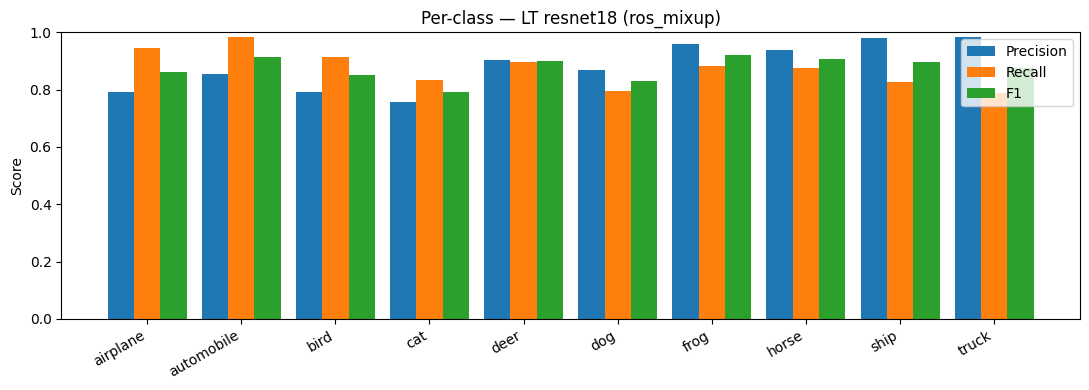

Saved per-class bars: figures/perclass_resnet18_LT_ros_mixup.png

--- LT | densenet121 | ros_mixup ---
Ep 01 | train_loss=1.759 acc=25.3%  val_loss=1.387 acc=51.5%
Ep 05 | train_loss=0.841 acc=45.8%  val_loss=0.895 acc=70.9%
Ep 10 | train_loss=0.666 acc=49.3%  val_loss=0.747 acc=76.3%
Ep 15 | train_loss=0.594 acc=49.8%  val_loss=0.704 acc=77.3%
Ep 20 | train_loss=0.568 acc=54.4%  val_loss=0.668 acc=79.1%
Ep 25 | train_loss=0.517 acc=53.7%  val_loss=0.608 acc=81.8%
Ep 30 | train_loss=0.477 acc=52.0%  val_loss=0.573 acc=82.9%
Ep 35 | train_loss=0.450 acc=61.6%  val_loss=0.604 acc=82.1%
Ep 40 | train_loss=0.386 acc=55.7%  val_loss=0.521 acc=85.5%
Ep 45 | train_loss=0.359 acc=56.9%  val_loss=0.503 acc=86.6%
Ep 50 | train_loss=0.336 acc=54.2%  val_loss=0.494 acc=86.9%
Final test — Acc 87.42% | Macro-F1 87.53% | Balanced Acc 87.42%

--- Classification report: LT | densenet121 | ros_mixup ---
              precision    recall  f1-score   support

    airplane       0.75      0.97      0.85   

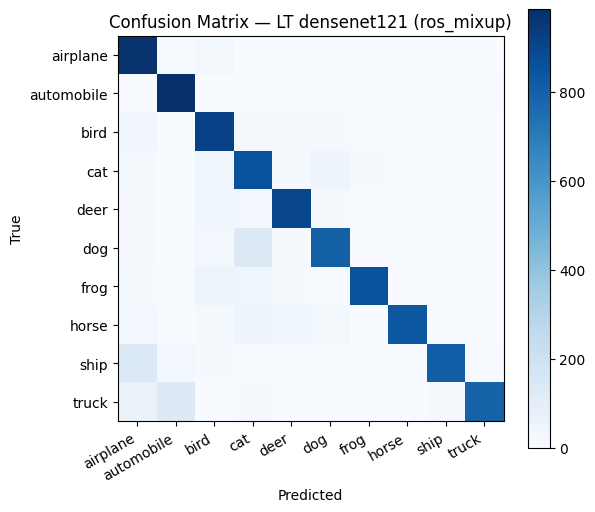

Saved confusion matrix: figures/cm_densenet121_LT_ros_mixup.png


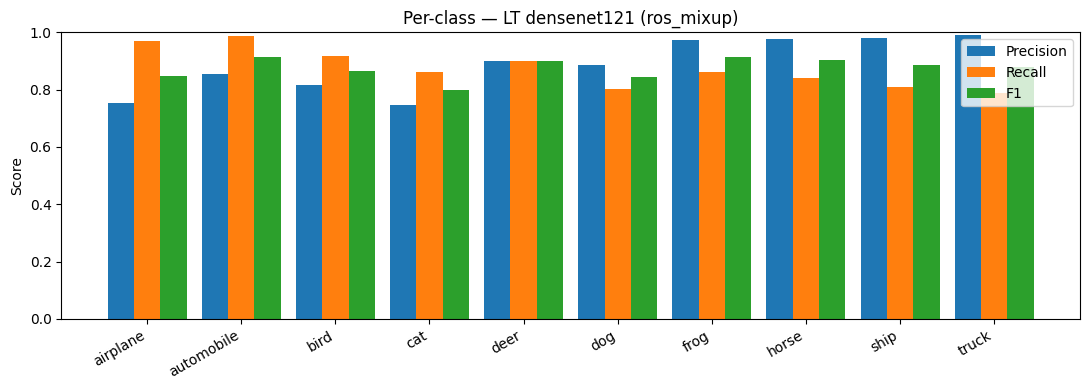

Saved per-class bars: figures/perclass_densenet121_LT_ros_mixup.png

================  ROS_MIXUP | Scenario: SS  ================

--- SS | resnet18 | ros_mixup ---
Ep 01 | train_loss=2.046 acc=20.8%  val_loss=1.549 acc=43.4%
Ep 05 | train_loss=0.955 acc=43.5%  val_loss=0.823 acc=72.6%
Ep 10 | train_loss=0.685 acc=50.5%  val_loss=0.676 acc=78.5%
Ep 15 | train_loss=0.655 acc=49.9%  val_loss=0.718 acc=77.4%
Ep 20 | train_loss=0.558 acc=48.9%  val_loss=0.639 acc=80.3%
Ep 25 | train_loss=0.548 acc=53.8%  val_loss=0.614 acc=82.0%
Ep 30 | train_loss=0.481 acc=54.1%  val_loss=0.566 acc=83.2%
Ep 35 | train_loss=0.465 acc=55.8%  val_loss=0.467 acc=86.6%
Ep 40 | train_loss=0.431 acc=53.1%  val_loss=0.467 acc=86.7%
Ep 45 | train_loss=0.389 acc=54.5%  val_loss=0.427 acc=88.1%
Ep 50 | train_loss=0.371 acc=56.1%  val_loss=0.446 acc=87.9%
Final test — Acc 88.61% | Macro-F1 88.63% | Balanced Acc 88.61%

--- Classification report: SS | resnet18 | ros_mixup ---
              precision    recall  f1-scor

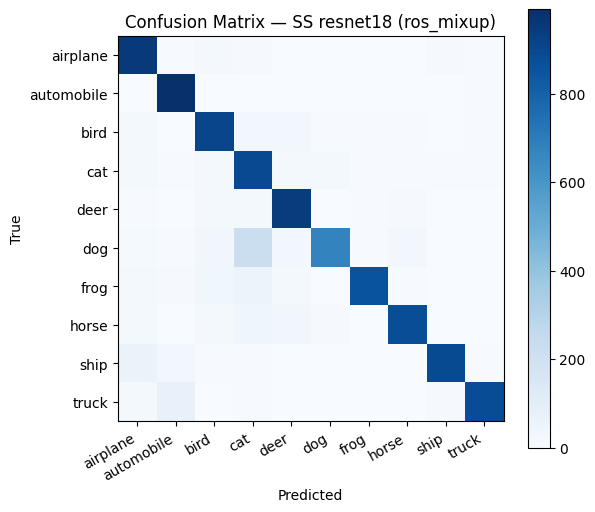

Saved confusion matrix: figures/cm_resnet18_SS_ros_mixup.png


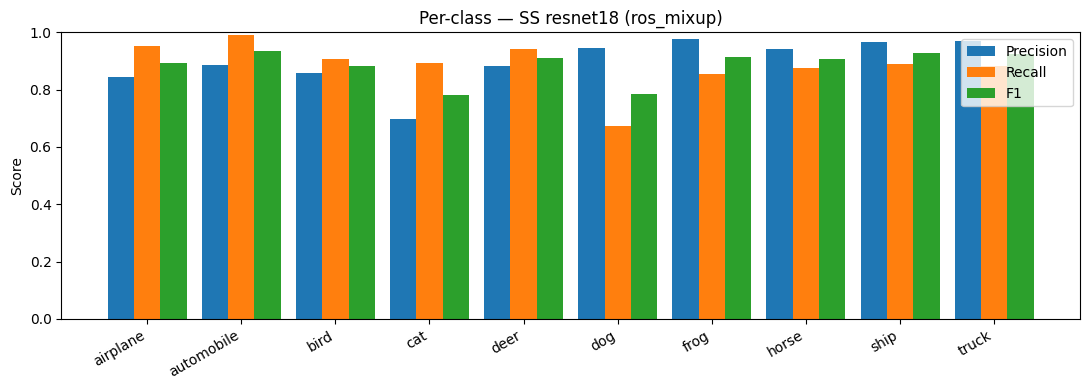

Saved per-class bars: figures/perclass_resnet18_SS_ros_mixup.png

--- SS | densenet121 | ros_mixup ---
Ep 01 | train_loss=1.708 acc=27.2%  val_loss=1.392 acc=51.2%
Ep 05 | train_loss=0.848 acc=50.6%  val_loss=1.084 acc=64.7%
Ep 10 | train_loss=0.685 acc=42.2%  val_loss=0.611 acc=80.4%
Ep 15 | train_loss=0.621 acc=48.0%  val_loss=0.786 acc=74.9%
Ep 20 | train_loss=0.589 acc=50.3%  val_loss=0.727 acc=77.5%
Ep 25 | train_loss=0.566 acc=51.6%  val_loss=0.550 acc=83.9%
Ep 30 | train_loss=0.500 acc=54.9%  val_loss=0.491 acc=85.8%
Ep 35 | train_loss=0.440 acc=54.2%  val_loss=0.567 acc=83.6%
Ep 40 | train_loss=0.423 acc=52.2%  val_loss=0.495 acc=86.8%
Ep 45 | train_loss=0.354 acc=55.5%  val_loss=0.505 acc=87.9%
Ep 50 | train_loss=0.377 acc=55.7%  val_loss=0.446 acc=88.3%
Final test — Acc 88.75% | Macro-F1 88.82% | Balanced Acc 88.75%

--- Classification report: SS | densenet121 | ros_mixup ---
              precision    recall  f1-score   support

    airplane       0.84      0.96      0.90   

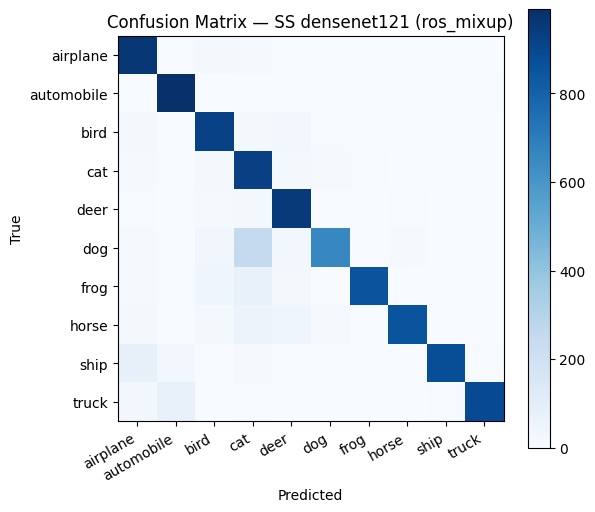

Saved confusion matrix: figures/cm_densenet121_SS_ros_mixup.png


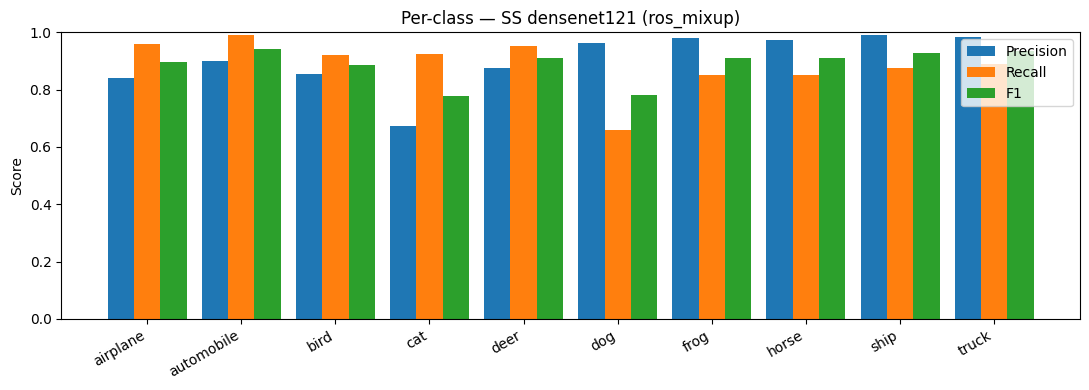

Saved per-class bars: figures/perclass_densenet121_SS_ros_mixup.png

================  ROS_MIXUP | Scenario: AS  ================

--- AS | resnet18 | ros_mixup ---
Ep 01 | train_loss=2.062 acc=19.3%  val_loss=1.617 acc=40.1%
Ep 05 | train_loss=1.061 acc=42.7%  val_loss=1.038 acc=65.1%
Ep 10 | train_loss=0.654 acc=50.0%  val_loss=0.901 acc=71.9%
Ep 15 | train_loss=0.542 acc=52.3%  val_loss=0.776 acc=76.3%
Ep 20 | train_loss=0.522 acc=51.8%  val_loss=0.812 acc=75.7%
Ep 25 | train_loss=0.472 acc=50.0%  val_loss=0.800 acc=75.2%
Ep 30 | train_loss=0.432 acc=55.7%  val_loss=0.648 acc=80.0%
Ep 35 | train_loss=0.463 acc=56.1%  val_loss=0.617 acc=82.3%
Ep 40 | train_loss=0.388 acc=58.0%  val_loss=0.568 acc=83.1%
Ep 45 | train_loss=0.391 acc=51.2%  val_loss=0.532 acc=84.2%
Ep 50 | train_loss=0.394 acc=54.3%  val_loss=0.527 acc=84.2%
Final test — Acc 84.42% | Macro-F1 84.42% | Balanced Acc 84.42%

--- Classification report: AS | resnet18 | ros_mixup ---
              precision    recall  f1-scor

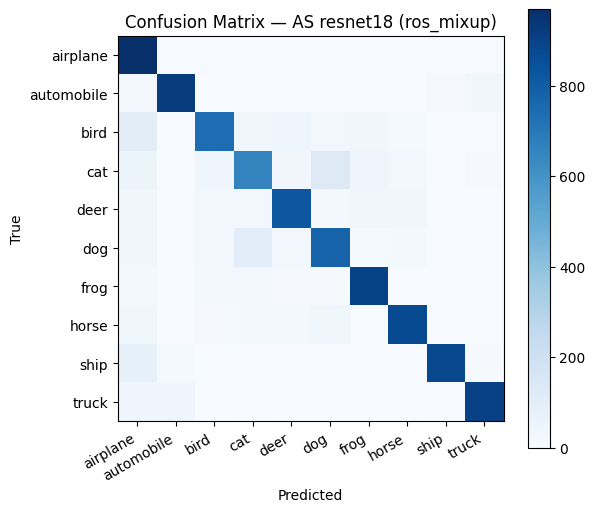

Saved confusion matrix: figures/cm_resnet18_AS_ros_mixup.png


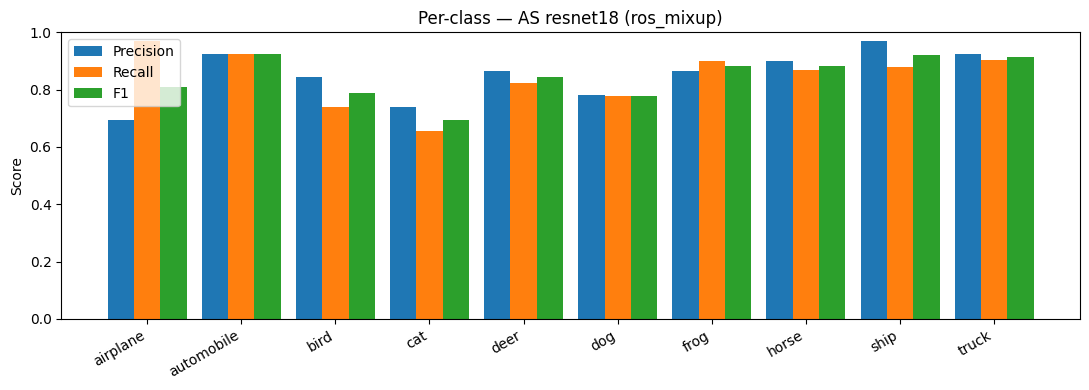

Saved per-class bars: figures/perclass_resnet18_AS_ros_mixup.png

--- AS | densenet121 | ros_mixup ---
Ep 01 | train_loss=1.845 acc=25.0%  val_loss=1.407 acc=49.9%
Ep 05 | train_loss=0.827 acc=47.7%  val_loss=1.002 acc=67.8%
Ep 10 | train_loss=0.619 acc=48.7%  val_loss=0.825 acc=74.6%
Ep 15 | train_loss=0.532 acc=51.4%  val_loss=0.720 acc=77.4%
Ep 20 | train_loss=0.541 acc=52.5%  val_loss=0.713 acc=77.5%
Ep 25 | train_loss=0.489 acc=56.7%  val_loss=0.692 acc=79.4%
Ep 30 | train_loss=0.414 acc=53.1%  val_loss=0.683 acc=79.5%
Ep 35 | train_loss=0.423 acc=56.0%  val_loss=0.589 acc=83.0%
Ep 40 | train_loss=0.411 acc=54.3%  val_loss=0.549 acc=84.2%
Ep 45 | train_loss=0.364 acc=56.9%  val_loss=0.582 acc=84.0%
Ep 50 | train_loss=0.373 acc=57.8%  val_loss=0.543 acc=85.0%
Final test — Acc 85.11% | Macro-F1 85.21% | Balanced Acc 85.11%

--- Classification report: AS | densenet121 | ros_mixup ---
              precision    recall  f1-score   support

    airplane       0.69      0.97      0.81   

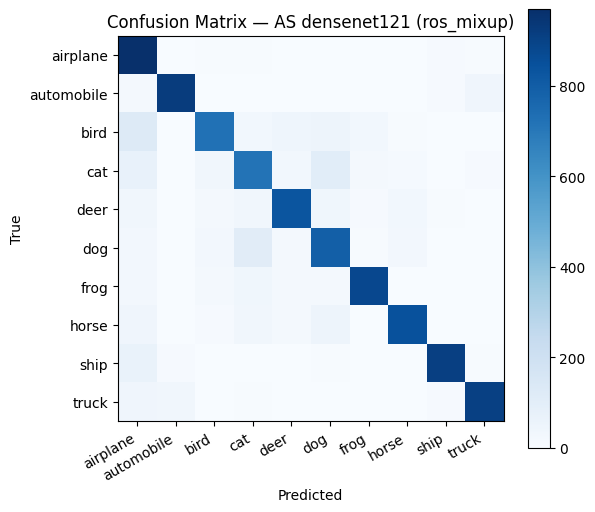

Saved confusion matrix: figures/cm_densenet121_AS_ros_mixup.png


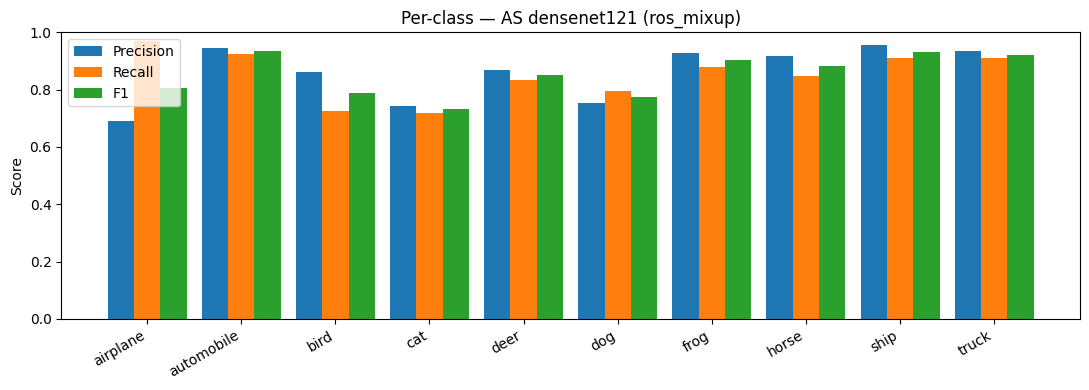

Saved per-class bars: figures/perclass_densenet121_AS_ros_mixup.png


,Scenario,Model,Macro-F1 (%),Balanced Acc (%),Overall Acc (%)
5,AS,densenet121,85.21,85.11,85.11
4,AS,resnet18,84.42,84.42,84.42
1,LT,densenet121,87.53,87.42,87.42
0,LT,resnet18,87.44,87.37,87.37
3,SS,densenet121,88.82,88.75,88.75
2,SS,resnet18,88.63,88.61,88.61


Saved summary: metrics/summary_ros_mixup.csv


In [36]:
# Random Oversampling + MixUp
CONFIG.update({"use_mixup": True, "use_cutmix": False, "use_patchmix": False})
run_experiment("ros_mixup", make_ros_loader)



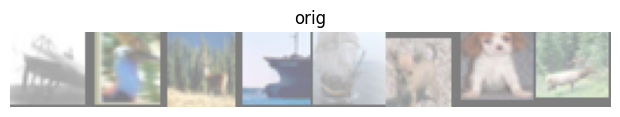

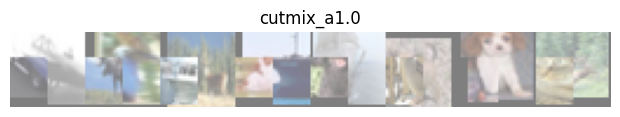


================  ROS_CUTMIX | Scenario: LT  ================

--- LT | resnet18 | ros_cutmix ---
Ep 01 | train_loss=2.292 acc=17.5%  val_loss=1.813 acc=31.9%
Ep 05 | train_loss=1.665 acc=44.5%  val_loss=1.371 acc=52.2%
Ep 10 | train_loss=1.371 acc=57.9%  val_loss=1.565 acc=53.6%
Ep 15 | train_loss=1.172 acc=64.0%  val_loss=0.868 acc=71.9%
Ep 20 | train_loss=1.123 acc=65.0%  val_loss=0.757 acc=76.4%
Ep 25 | train_loss=0.989 acc=69.5%  val_loss=0.729 acc=78.1%
Ep 30 | train_loss=0.888 acc=75.1%  val_loss=0.643 acc=80.8%
Ep 35 | train_loss=0.839 acc=74.0%  val_loss=0.544 acc=83.9%
Ep 40 | train_loss=0.713 acc=81.3%  val_loss=0.643 acc=80.8%
Ep 45 | train_loss=0.657 acc=81.7%  val_loss=0.590 acc=82.0%
Ep 50 | train_loss=0.640 acc=82.0%  val_loss=0.617 acc=81.8%
Final test — Acc 84.79% | Macro-F1 84.88% | Balanced Acc 84.79%

--- Classification report: LT | resnet18 | ros_cutmix ---
              precision    recall  f1-score   support

    airplane       0.83      0.92      0.87      100

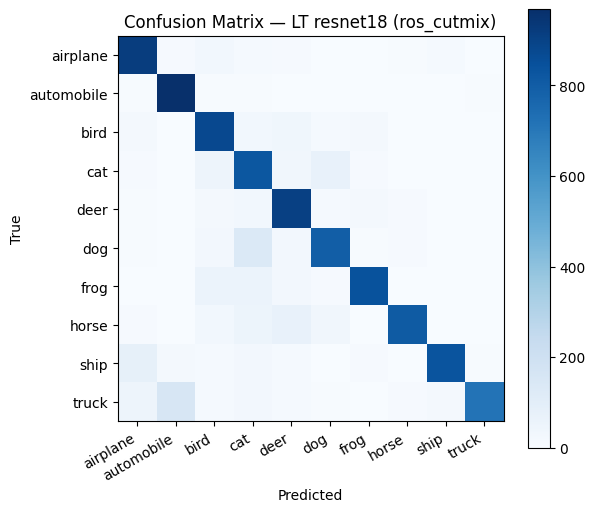

Saved confusion matrix: figures/cm_resnet18_LT_ros_cutmix.png


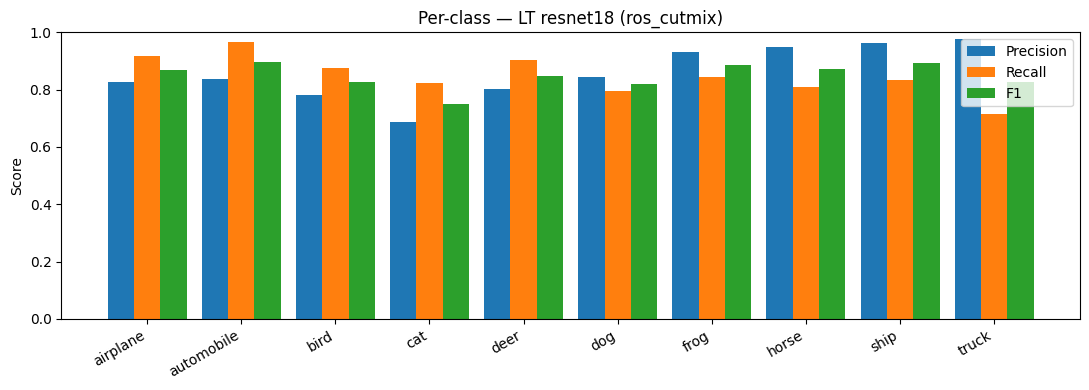

Saved per-class bars: figures/perclass_resnet18_LT_ros_cutmix.png

--- LT | densenet121 | ros_cutmix ---
Ep 01 | train_loss=1.976 acc=30.7%  val_loss=1.528 acc=44.5%
Ep 05 | train_loss=1.376 acc=56.5%  val_loss=0.983 acc=66.7%
Ep 10 | train_loss=1.137 acc=67.3%  val_loss=0.904 acc=71.6%
Ep 15 | train_loss=1.056 acc=69.1%  val_loss=0.727 acc=78.6%
Ep 20 | train_loss=0.972 acc=71.6%  val_loss=0.739 acc=76.2%
Ep 25 | train_loss=0.886 acc=75.7%  val_loss=0.705 acc=76.6%
Ep 30 | train_loss=0.828 acc=76.8%  val_loss=0.514 acc=84.2%
Ep 35 | train_loss=0.734 acc=81.3%  val_loss=0.633 acc=80.6%
Ep 40 | train_loss=0.643 acc=82.4%  val_loss=0.618 acc=82.4%
Ep 45 | train_loss=0.571 acc=85.8%  val_loss=0.638 acc=81.6%
Ep 50 | train_loss=0.567 acc=85.1%  val_loss=0.646 acc=81.5%
Final test — Acc 84.24% | Macro-F1 84.17% | Balanced Acc 84.24%

--- Classification report: LT | densenet121 | ros_cutmix ---
              precision    recall  f1-score   support

    airplane       0.80      0.90      0.85

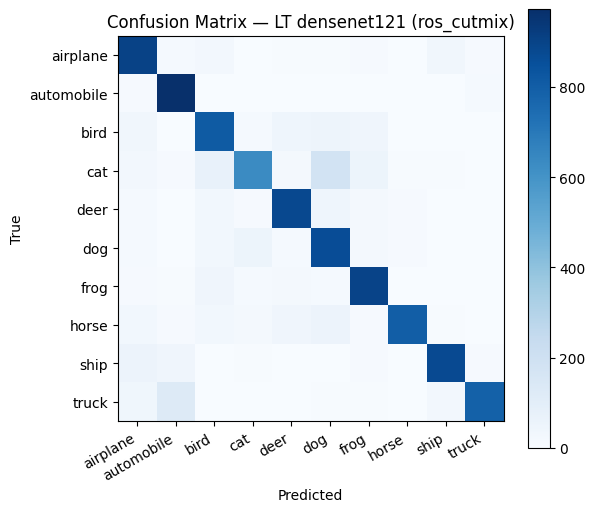

Saved confusion matrix: figures/cm_densenet121_LT_ros_cutmix.png


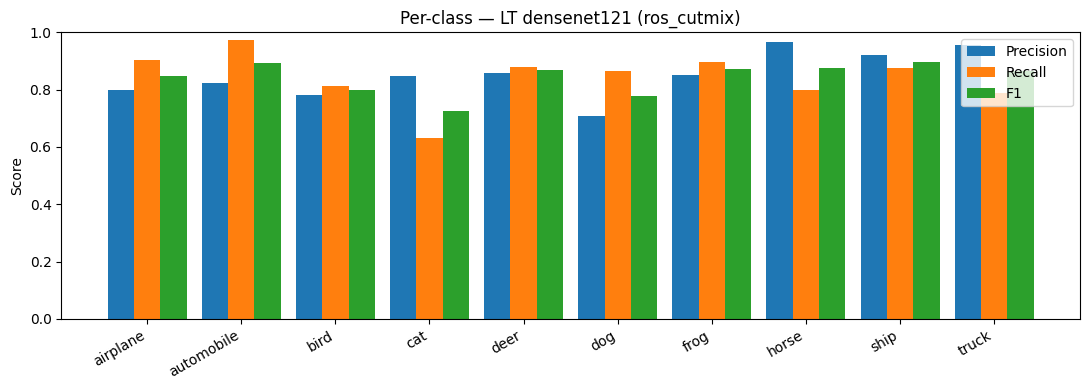

Saved per-class bars: figures/perclass_densenet121_LT_ros_cutmix.png

================  ROS_CUTMIX | Scenario: SS  ================

--- SS | resnet18 | ros_cutmix ---
Ep 01 | train_loss=2.265 acc=19.5%  val_loss=1.726 acc=35.4%
Ep 05 | train_loss=1.637 acc=44.8%  val_loss=1.181 acc=58.6%
Ep 10 | train_loss=1.350 acc=58.1%  val_loss=0.809 acc=74.2%
Ep 15 | train_loss=1.177 acc=64.8%  val_loss=0.733 acc=76.9%
Ep 20 | train_loss=1.121 acc=66.6%  val_loss=0.642 acc=80.7%
Ep 25 | train_loss=1.022 acc=71.2%  val_loss=0.679 acc=78.9%
Ep 30 | train_loss=0.917 acc=74.4%  val_loss=0.546 acc=83.5%
Ep 35 | train_loss=0.860 acc=76.8%  val_loss=0.550 acc=83.3%
Ep 40 | train_loss=0.777 acc=77.8%  val_loss=0.491 acc=85.2%
Ep 45 | train_loss=0.680 acc=82.3%  val_loss=0.514 acc=85.1%
Ep 50 | train_loss=0.653 acc=83.6%  val_loss=0.522 acc=84.5%
Final test — Acc 86.27% | Macro-F1 86.19% | Balanced Acc 86.27%

--- Classification report: SS | resnet18 | ros_cutmix ---
              precision    recall  f1-

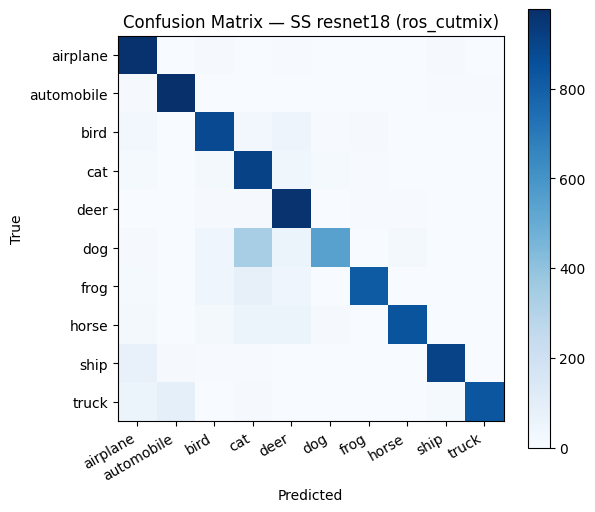

Saved confusion matrix: figures/cm_resnet18_SS_ros_cutmix.png


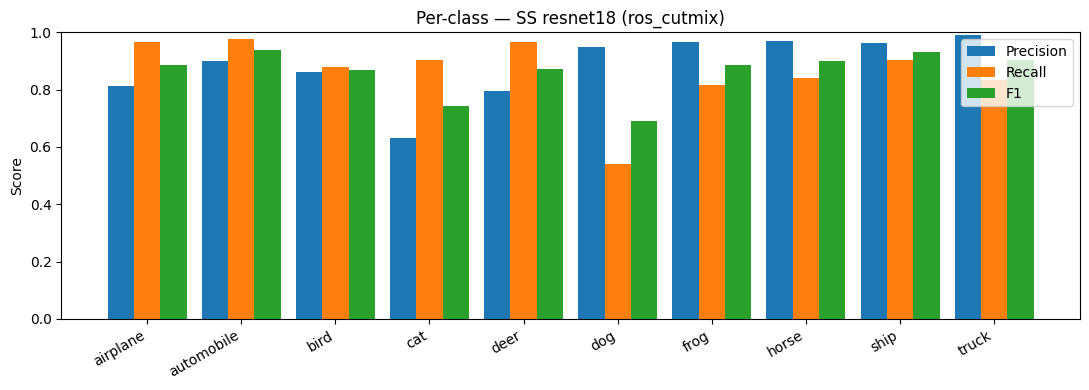

Saved per-class bars: figures/perclass_resnet18_SS_ros_cutmix.png

--- SS | densenet121 | ros_cutmix ---
Ep 01 | train_loss=2.002 acc=29.9%  val_loss=1.536 acc=44.8%
Ep 05 | train_loss=1.450 acc=53.8%  val_loss=1.083 acc=62.0%
Ep 10 | train_loss=1.190 acc=63.8%  val_loss=0.926 acc=69.5%
Ep 15 | train_loss=1.099 acc=67.1%  val_loss=0.657 acc=79.8%
Ep 20 | train_loss=1.031 acc=68.4%  val_loss=0.701 acc=78.7%
Ep 25 | train_loss=0.940 acc=72.3%  val_loss=0.525 acc=84.9%
Ep 30 | train_loss=0.855 acc=76.0%  val_loss=0.650 acc=79.8%
Ep 35 | train_loss=0.768 acc=78.8%  val_loss=0.619 acc=81.8%
Ep 40 | train_loss=0.705 acc=77.8%  val_loss=0.523 acc=83.2%
Ep 45 | train_loss=0.608 acc=84.7%  val_loss=0.564 acc=84.7%
Ep 50 | train_loss=0.592 acc=82.2%  val_loss=0.651 acc=83.2%
Final test — Acc 86.95% | Macro-F1 87.10% | Balanced Acc 86.95%

--- Classification report: SS | densenet121 | ros_cutmix ---
              precision    recall  f1-score   support

    airplane       0.88      0.95      0.91

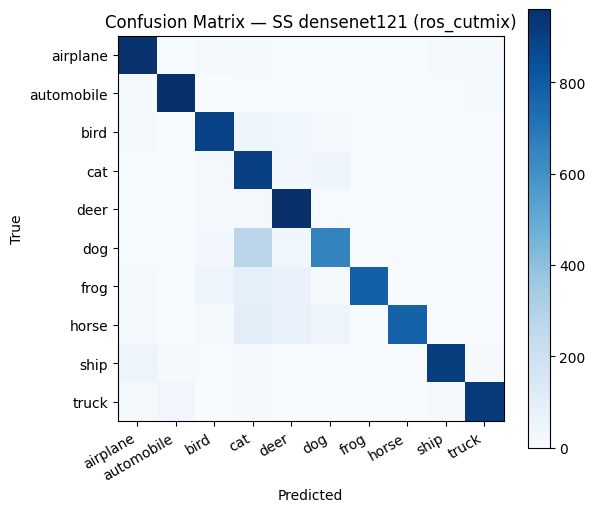

Saved confusion matrix: figures/cm_densenet121_SS_ros_cutmix.png


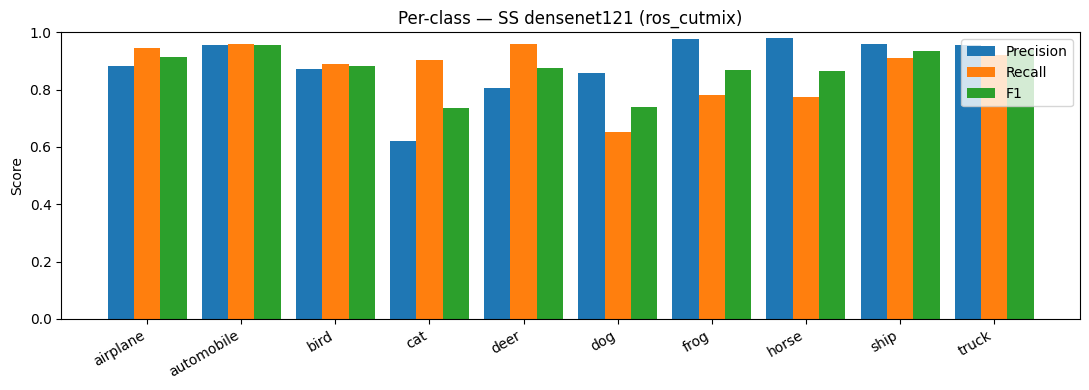

Saved per-class bars: figures/perclass_densenet121_SS_ros_cutmix.png

================  ROS_CUTMIX | Scenario: AS  ================

--- AS | resnet18 | ros_cutmix ---
Ep 01 | train_loss=2.240 acc=19.1%  val_loss=1.761 acc=34.2%
Ep 05 | train_loss=1.617 acc=46.4%  val_loss=1.268 acc=55.0%
Ep 10 | train_loss=1.320 acc=59.1%  val_loss=0.948 acc=69.3%
Ep 15 | train_loss=1.145 acc=66.5%  val_loss=0.870 acc=71.9%
Ep 20 | train_loss=0.986 acc=71.9%  val_loss=0.654 acc=79.5%
Ep 25 | train_loss=0.936 acc=74.2%  val_loss=0.817 acc=74.6%
Ep 30 | train_loss=0.847 acc=75.9%  val_loss=0.931 acc=72.0%
Ep 35 | train_loss=0.737 acc=78.6%  val_loss=0.730 acc=78.0%
Ep 40 | train_loss=0.676 acc=81.8%  val_loss=0.607 acc=81.8%
Ep 45 | train_loss=0.605 acc=86.1%  val_loss=0.636 acc=81.5%
Ep 50 | train_loss=0.597 acc=85.9%  val_loss=0.604 acc=81.6%
Final test — Acc 82.78% | Macro-F1 82.89% | Balanced Acc 82.78%

--- Classification report: AS | resnet18 | ros_cutmix ---
              precision    recall  f1-

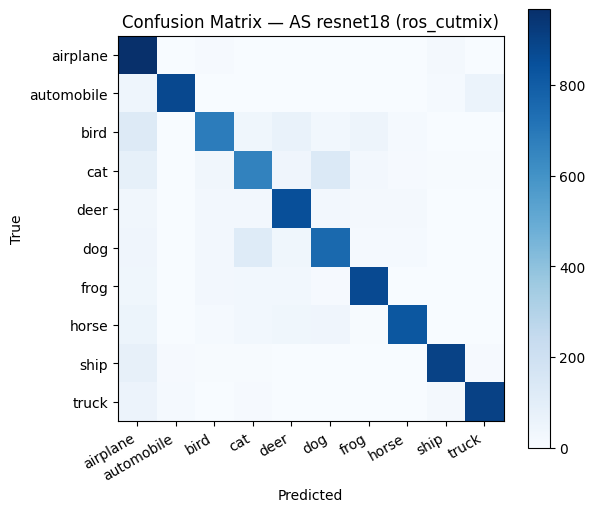

Saved confusion matrix: figures/cm_resnet18_AS_ros_cutmix.png


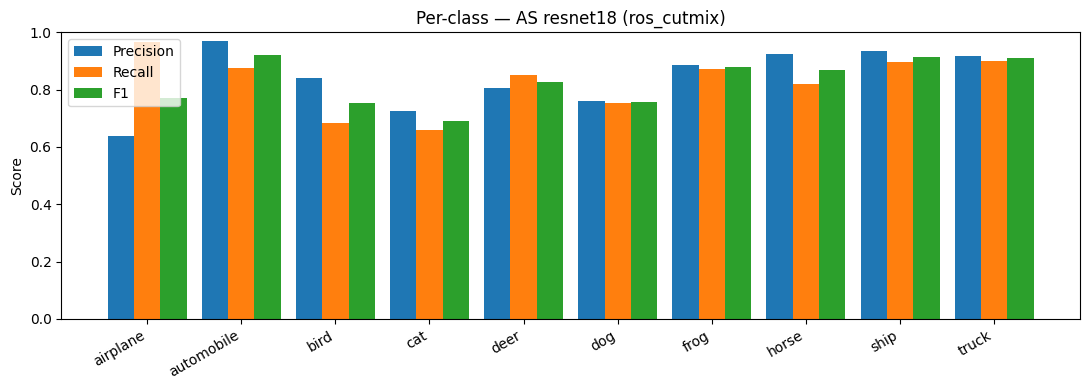

Saved per-class bars: figures/perclass_resnet18_AS_ros_cutmix.png

--- AS | densenet121 | ros_cutmix ---
Ep 01 | train_loss=2.006 acc=28.9%  val_loss=1.490 acc=45.5%
Ep 05 | train_loss=1.350 acc=58.8%  val_loss=1.003 acc=66.9%
Ep 10 | train_loss=1.119 acc=65.8%  val_loss=0.877 acc=70.7%
Ep 15 | train_loss=1.000 acc=71.7%  val_loss=0.808 acc=75.0%
Ep 20 | train_loss=0.928 acc=72.6%  val_loss=0.803 acc=76.4%
Ep 25 | train_loss=0.817 acc=78.5%  val_loss=0.751 acc=76.4%
Ep 30 | train_loss=0.732 acc=79.7%  val_loss=0.729 acc=76.8%
Ep 35 | train_loss=0.664 acc=82.6%  val_loss=0.627 acc=81.2%
Ep 40 | train_loss=0.599 acc=84.4%  val_loss=0.582 acc=83.1%
Ep 45 | train_loss=0.549 acc=84.3%  val_loss=0.598 acc=82.5%
Ep 50 | train_loss=0.527 acc=85.8%  val_loss=0.587 acc=82.4%
Final test — Acc 83.43% | Macro-F1 83.52% | Balanced Acc 83.43%

--- Classification report: AS | densenet121 | ros_cutmix ---
              precision    recall  f1-score   support

    airplane       0.70      0.97      0.81

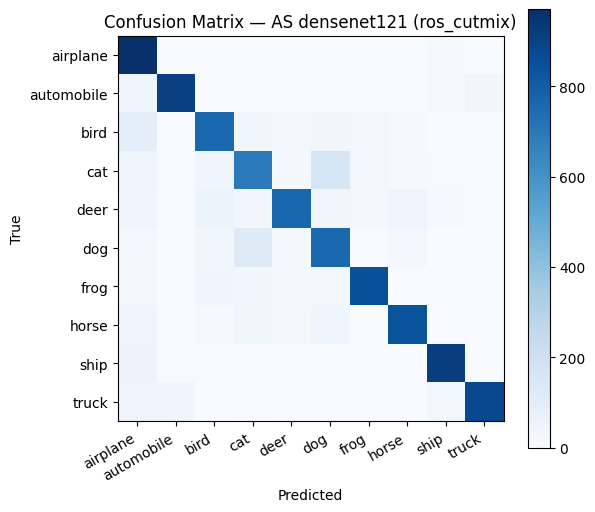

Saved confusion matrix: figures/cm_densenet121_AS_ros_cutmix.png


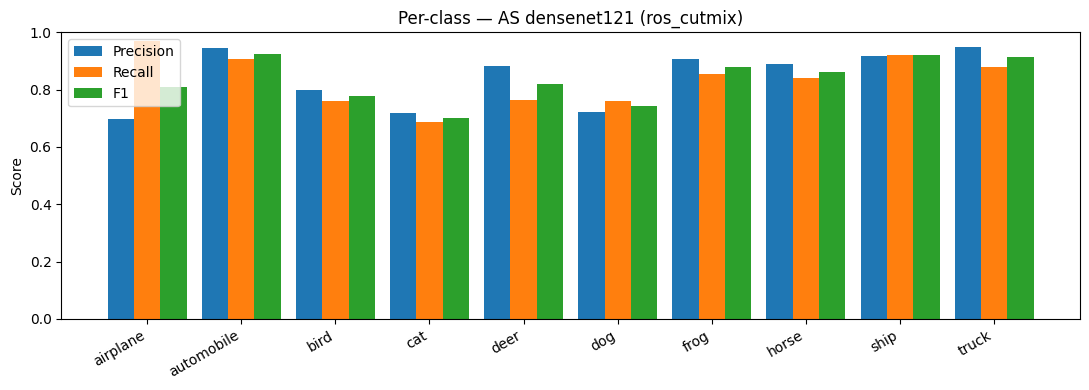

Saved per-class bars: figures/perclass_densenet121_AS_ros_cutmix.png


,Scenario,Model,Macro-F1 (%),Balanced Acc (%),Overall Acc (%)
5,AS,densenet121,83.52,83.43,83.43
4,AS,resnet18,82.89,82.78,82.78
1,LT,densenet121,84.17,84.24,84.24
0,LT,resnet18,84.88,84.79,84.79
3,SS,densenet121,87.10,86.95,86.95
2,SS,resnet18,86.19,86.27,86.27


Saved summary: metrics/summary_ros_cutmix.csv


In [12]:
#  Random Oversampling + CutMix
CONFIG.update({"use_mixup": False, "use_cutmix": True, "use_patchmix": False})
run_experiment("ros_cutmix", make_ros_loader)


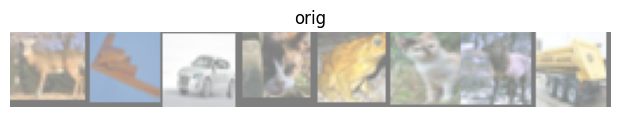

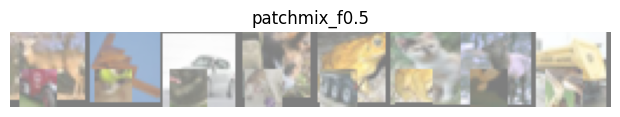


================  ROS_PATCHMIX | Scenario: LT  ================

--- LT | resnet18 | ros_patchmix ---
Ep 01 | train_loss=2.379 acc=17.2%  val_loss=1.905 acc=30.2%
Ep 05 | train_loss=1.877 acc=39.7%  val_loss=1.331 acc=53.7%
Ep 10 | train_loss=1.649 acc=47.6%  val_loss=1.192 acc=58.2%
Ep 15 | train_loss=1.489 acc=51.9%  val_loss=1.118 acc=60.4%
Ep 20 | train_loss=1.358 acc=55.2%  val_loss=0.788 acc=75.2%
Ep 25 | train_loss=1.258 acc=57.9%  val_loss=0.777 acc=75.6%
Ep 30 | train_loss=1.158 acc=60.9%  val_loss=0.633 acc=80.3%
Ep 35 | train_loss=1.048 acc=63.7%  val_loss=0.735 acc=76.8%
Ep 40 | train_loss=0.940 acc=66.5%  val_loss=0.630 acc=81.7%
Ep 45 | train_loss=0.840 acc=69.2%  val_loss=0.609 acc=82.8%
Ep 50 | train_loss=0.803 acc=69.4%  val_loss=0.590 acc=83.0%
Final test — Acc 84.07% | Macro-F1 84.11% | Balanced Acc 84.07%

--- Classification report: LT | resnet18 | ros_patchmix ---
              precision    recall  f1-score   support

    airplane       0.76      0.95      0.84   

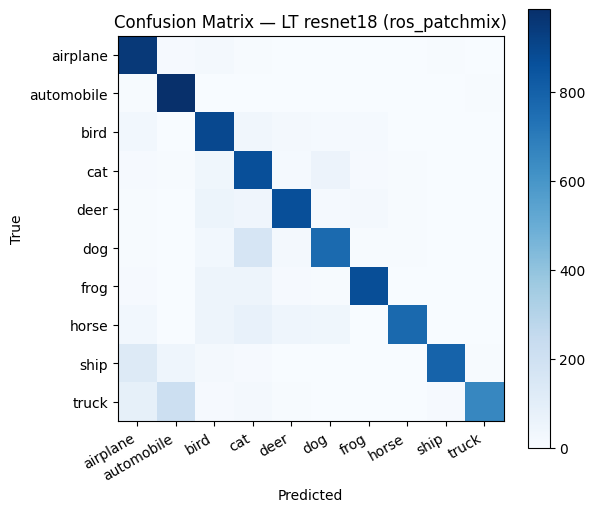

Saved confusion matrix: figures/cm_resnet18_LT_ros_patchmix.png


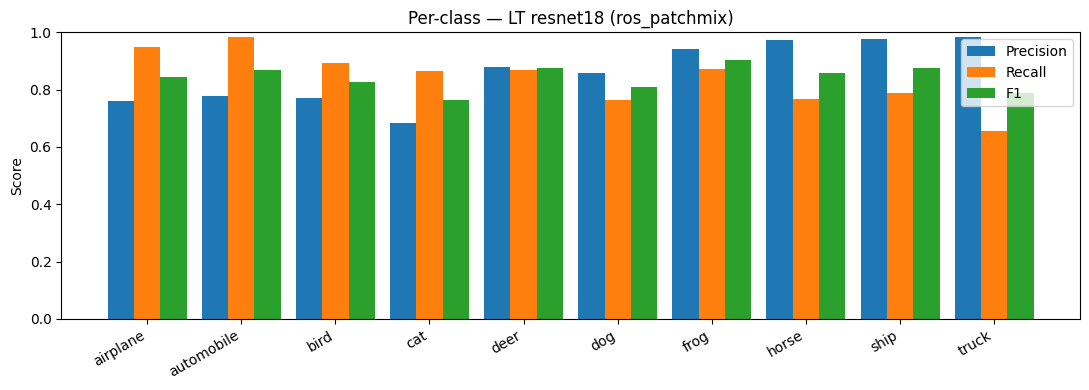

Saved per-class bars: figures/perclass_resnet18_LT_ros_patchmix.png

--- LT | densenet121 | ros_patchmix ---
Ep 01 | train_loss=2.120 acc=28.3%  val_loss=1.653 acc=37.9%
Ep 05 | train_loss=1.688 acc=48.2%  val_loss=1.203 acc=58.8%
Ep 10 | train_loss=1.445 acc=53.4%  val_loss=0.938 acc=70.8%
Ep 15 | train_loss=1.324 acc=55.9%  val_loss=0.829 acc=73.9%
Ep 20 | train_loss=1.219 acc=58.5%  val_loss=0.681 acc=78.4%
Ep 25 | train_loss=1.126 acc=60.5%  val_loss=0.648 acc=79.9%
Ep 30 | train_loss=1.022 acc=62.0%  val_loss=0.723 acc=76.5%
Ep 35 | train_loss=0.920 acc=63.7%  val_loss=0.568 acc=82.8%
Ep 40 | train_loss=0.819 acc=66.0%  val_loss=0.586 acc=83.0%
Ep 45 | train_loss=0.728 acc=65.1%  val_loss=0.648 acc=82.1%
Ep 50 | train_loss=0.696 acc=62.2%  val_loss=0.747 acc=80.2%
Final test — Acc 84.34% | Macro-F1 84.39% | Balanced Acc 84.34%

--- Classification report: LT | densenet121 | ros_patchmix ---
              precision    recall  f1-score   support

    airplane       0.78      0.93    

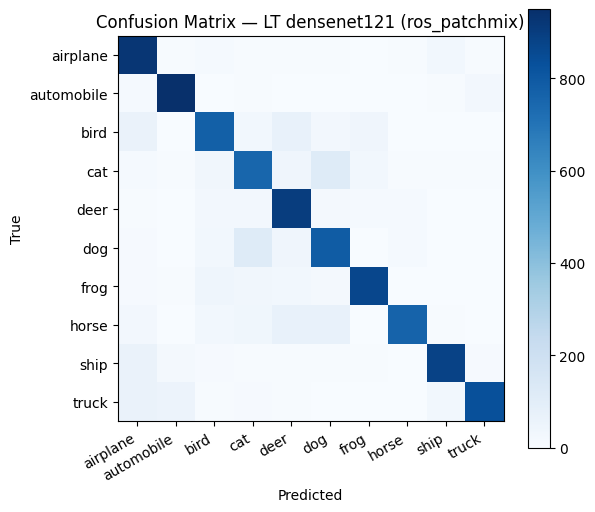

Saved confusion matrix: figures/cm_densenet121_LT_ros_patchmix.png


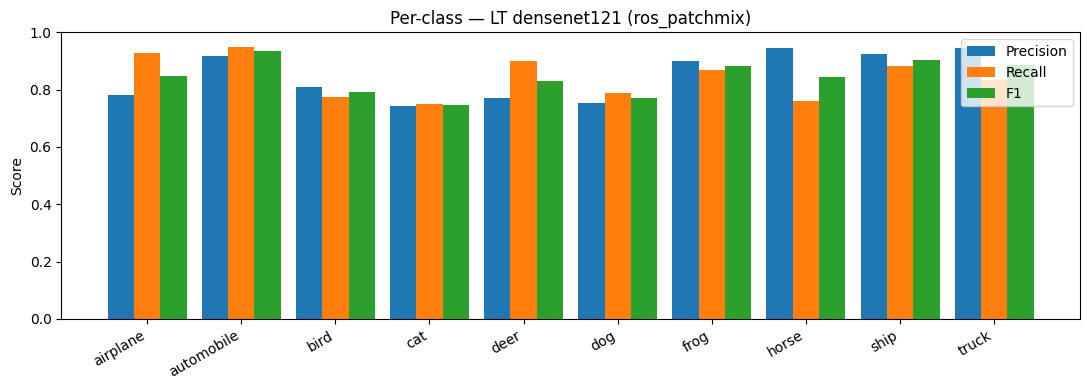

Saved per-class bars: figures/perclass_densenet121_LT_ros_patchmix.png

================  ROS_PATCHMIX | Scenario: SS  ================

--- SS | resnet18 | ros_patchmix ---
Ep 01 | train_loss=2.344 acc=15.7%  val_loss=1.916 acc=28.2%
Ep 05 | train_loss=1.851 acc=40.8%  val_loss=1.315 acc=56.4%
Ep 10 | train_loss=1.618 acc=49.6%  val_loss=0.951 acc=70.1%
Ep 15 | train_loss=1.473 acc=52.9%  val_loss=0.807 acc=74.6%
Ep 20 | train_loss=1.367 acc=55.6%  val_loss=0.744 acc=77.4%
Ep 25 | train_loss=1.276 acc=58.1%  val_loss=0.636 acc=79.7%
Ep 30 | train_loss=1.176 acc=60.8%  val_loss=0.607 acc=82.3%
Ep 35 | train_loss=1.075 acc=63.8%  val_loss=0.522 acc=84.7%
Ep 40 | train_loss=0.963 acc=67.7%  val_loss=0.477 acc=85.8%
Ep 45 | train_loss=0.863 acc=68.3%  val_loss=0.471 acc=86.5%
Ep 50 | train_loss=0.825 acc=70.1%  val_loss=0.499 acc=85.6%
Final test — Acc 86.46% | Macro-F1 86.47% | Balanced Acc 86.46%

--- Classification report: SS | resnet18 | ros_patchmix ---
              precision    rec

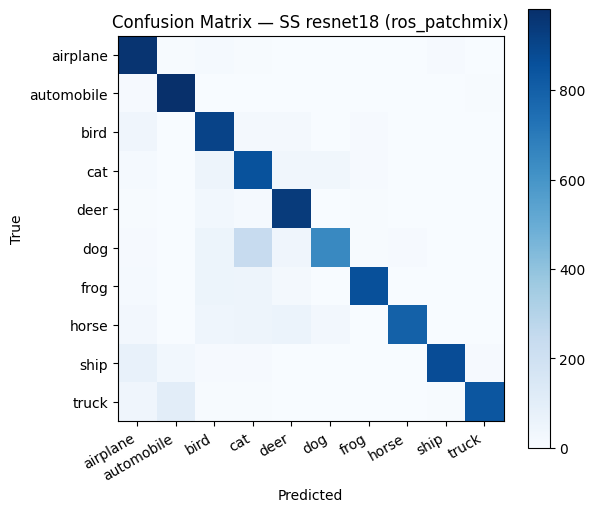

Saved confusion matrix: figures/cm_resnet18_SS_ros_patchmix.png


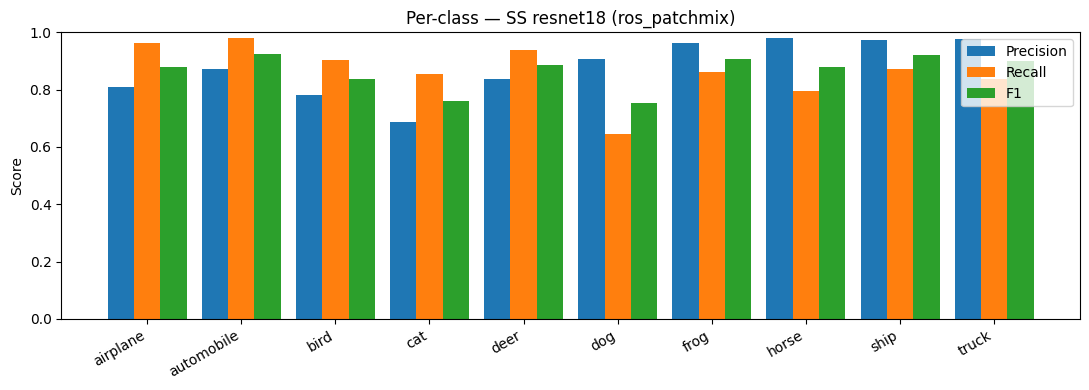

Saved per-class bars: figures/perclass_resnet18_SS_ros_patchmix.png

--- SS | densenet121 | ros_patchmix ---
Ep 01 | train_loss=2.131 acc=28.4%  val_loss=1.636 acc=42.2%
Ep 05 | train_loss=1.693 acc=48.5%  val_loss=1.084 acc=64.5%
Ep 10 | train_loss=1.465 acc=53.0%  val_loss=0.781 acc=75.7%
Ep 15 | train_loss=1.357 acc=56.6%  val_loss=0.767 acc=74.0%
Ep 20 | train_loss=1.266 acc=57.8%  val_loss=0.704 acc=77.3%
Ep 25 | train_loss=1.174 acc=60.6%  val_loss=0.596 acc=81.0%
Ep 30 | train_loss=1.074 acc=62.1%  val_loss=0.606 acc=81.7%
Ep 35 | train_loss=0.972 acc=64.7%  val_loss=0.626 acc=81.9%
Ep 40 | train_loss=0.856 acc=65.1%  val_loss=0.583 acc=82.7%
Ep 45 | train_loss=0.767 acc=63.5%  val_loss=0.625 acc=83.3%
Ep 50 | train_loss=0.733 acc=64.0%  val_loss=0.627 acc=83.1%
Final test — Acc 84.97% | Macro-F1 84.97% | Balanced Acc 84.97%

--- Classification report: SS | densenet121 | ros_patchmix ---
              precision    recall  f1-score   support

    airplane       0.80      0.95    

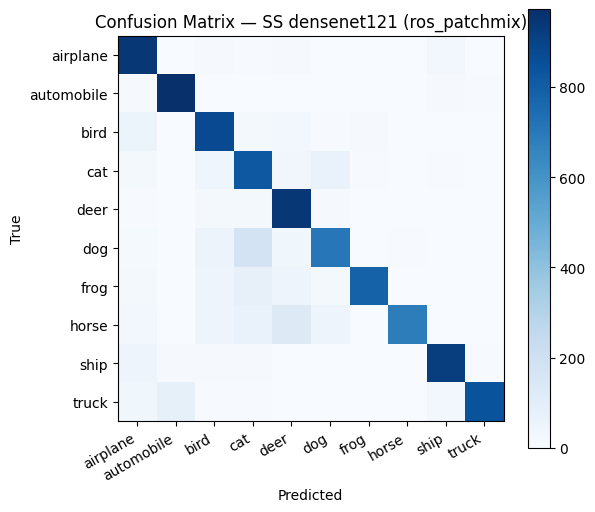

Saved confusion matrix: figures/cm_densenet121_SS_ros_patchmix.png


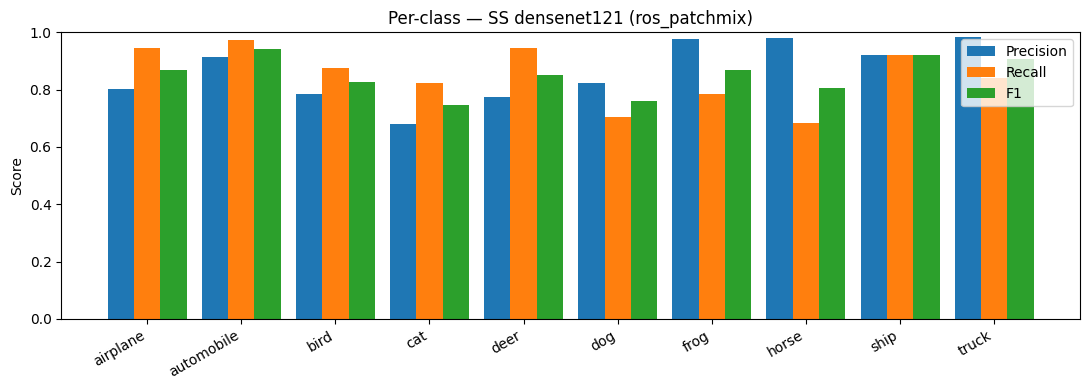

Saved per-class bars: figures/perclass_densenet121_SS_ros_patchmix.png

================  ROS_PATCHMIX | Scenario: AS  ================

--- AS | resnet18 | ros_patchmix ---
Ep 01 | train_loss=2.312 acc=16.6%  val_loss=1.855 acc=29.0%
Ep 05 | train_loss=1.901 acc=38.4%  val_loss=1.321 acc=56.7%
Ep 10 | train_loss=1.623 acc=49.6%  val_loss=0.989 acc=68.2%
Ep 15 | train_loss=1.439 acc=53.8%  val_loss=0.856 acc=72.1%
Ep 20 | train_loss=1.302 acc=57.3%  val_loss=0.901 acc=71.1%
Ep 25 | train_loss=1.192 acc=60.1%  val_loss=0.753 acc=75.8%
Ep 30 | train_loss=1.066 acc=63.4%  val_loss=0.657 acc=79.3%
Ep 35 | train_loss=0.951 acc=67.2%  val_loss=0.665 acc=78.7%
Ep 40 | train_loss=0.832 acc=70.1%  val_loss=0.599 acc=82.0%
Ep 45 | train_loss=0.742 acc=70.2%  val_loss=0.573 acc=82.7%
Ep 50 | train_loss=0.712 acc=70.2%  val_loss=0.573 acc=82.9%
Final test — Acc 83.07% | Macro-F1 83.19% | Balanced Acc 83.07%

--- Classification report: AS | resnet18 | ros_patchmix ---
              precision    rec

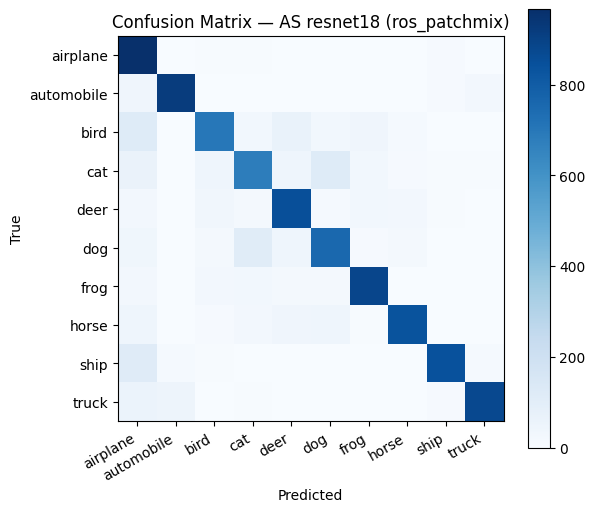

Saved confusion matrix: figures/cm_resnet18_AS_ros_patchmix.png


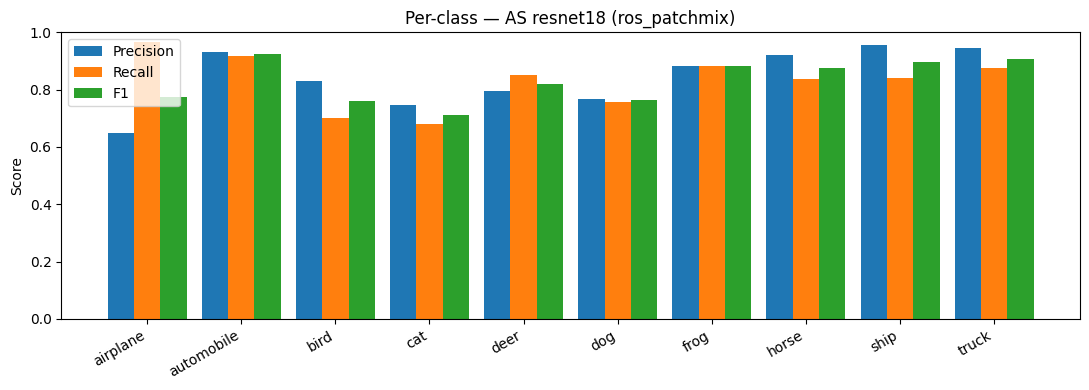

Saved per-class bars: figures/perclass_resnet18_AS_ros_patchmix.png

--- AS | densenet121 | ros_patchmix ---
Ep 01 | train_loss=2.159 acc=26.0%  val_loss=1.608 acc=40.5%
Ep 05 | train_loss=1.724 acc=46.8%  val_loss=1.131 acc=63.0%
Ep 10 | train_loss=1.456 acc=54.0%  val_loss=1.121 acc=61.0%
Ep 15 | train_loss=1.301 acc=57.9%  val_loss=0.769 acc=75.2%
Ep 20 | train_loss=1.167 acc=61.0%  val_loss=0.736 acc=76.0%
Ep 25 | train_loss=1.041 acc=63.4%  val_loss=0.701 acc=76.8%
Ep 30 | train_loss=0.922 acc=63.9%  val_loss=0.799 acc=74.4%
Ep 35 | train_loss=0.817 acc=64.1%  val_loss=0.754 acc=76.1%
Ep 40 | train_loss=0.729 acc=63.0%  val_loss=0.671 acc=80.5%
Ep 45 | train_loss=0.667 acc=60.2%  val_loss=0.718 acc=79.4%
Ep 50 | train_loss=0.651 acc=58.6%  val_loss=0.660 acc=81.0%
Final test — Acc 81.27% | Macro-F1 81.47% | Balanced Acc 81.27%

--- Classification report: AS | densenet121 | ros_patchmix ---
              precision    recall  f1-score   support

    airplane       0.60      0.99    

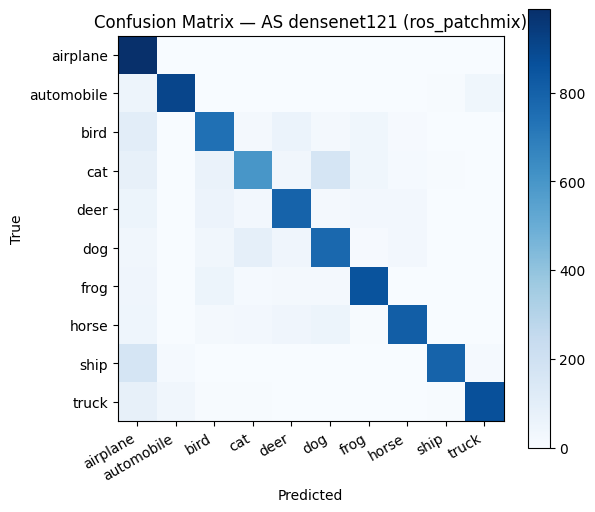

Saved confusion matrix: figures/cm_densenet121_AS_ros_patchmix.png


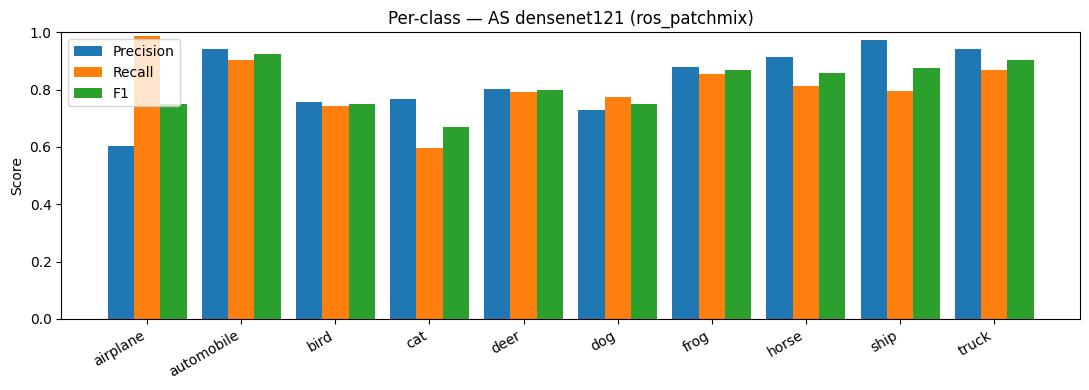

Saved per-class bars: figures/perclass_densenet121_AS_ros_patchmix.png


,Scenario,Model,Macro-F1 (%),Balanced Acc (%),Overall Acc (%)
5,AS,densenet121,81.47,81.27,81.27
4,AS,resnet18,83.19,83.07,83.07
1,LT,densenet121,84.39,84.34,84.34
0,LT,resnet18,84.11,84.07,84.07
3,SS,densenet121,84.97,84.97,84.97
2,SS,resnet18,86.47,86.46,86.46


Saved summary: metrics/summary_ros_patchmix.csv


In [13]:

# Random Oversampling + PatchMix
CONFIG.update({"use_mixup": False, "use_cutmix": False, "use_patchmix": True})
run_experiment("ros_patchmix", make_ros_loader)